In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.interpolate import griddata
from scipy.stats import qmc 
from scipy import stats
import time
import gurobipy as gp
import pandas as pd
from matplotlib.patches import Polygon


In [2]:
color_0='#e7e7e7'#lightest grey
color_1='#161616'#darkest black
color_1='#756F6C'#median grey
color_1='#adb5bd'
color_2='#39FF14'#medium green
color_2='black'
color_3='#b4b4b4'#median grey
color_4='#0075A2'#median grey
color_5='#FFD700'#median orange

In [3]:
results_df = pd.read_csv("cvar_results_lip.csv")
mean_loss_column = results_df['Mean_Loss'].to_numpy()
cvar_column = results_df['CVaR'].to_numpy()

# Read the actual w1, w2 data points from the CSV file
W1_data = results_df['w1'].to_numpy()
W2_data = results_df['w2'].to_numpy()
feasible_region = np.column_stack((W1_data, W2_data))

# Create a 2D grid for plotting

W1, W2 = np.meshgrid(W1_data, W2_data)
# Remove duplicate points
W1=np.unique(W1)
W2=np.unique(W2)
W1, W2 = np.meshgrid(W1, W2)


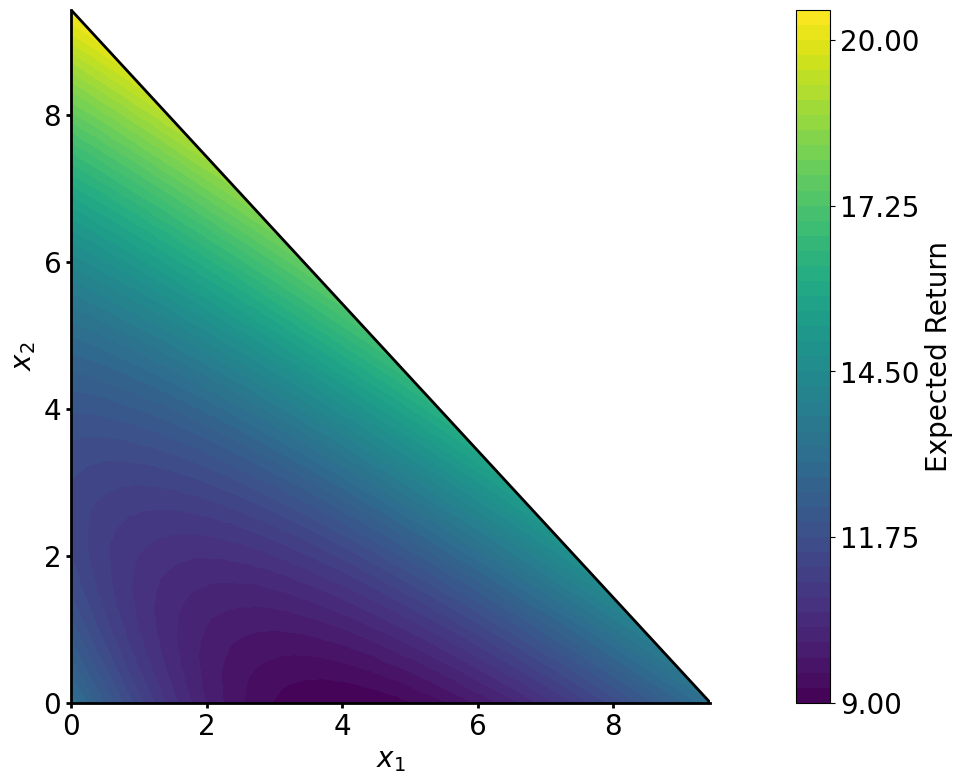

In [4]:


# Convert to numpy array
expected_returns = np.array(mean_loss_column)

# Interpolate onto a regular grid
grid_expected_return = griddata(
    (feasible_region[:, 0], feasible_region[:, 1]), 
    expected_returns, 
    (W1, W2), 
    method='cubic'
)

# Plot the filled contour map of expected return
plt.figure(figsize=(11, 9))
contour = plt.contourf(W1, W2, grid_expected_return, levels=50, cmap='viridis')

# Add heatmap colorbar
cbar = plt.colorbar(contour, pad=0.1,ticks=np.linspace(9,20,5))  # Reduce ticks
cbar.set_label('Expected Return', fontsize=20)  # LaTeX formatted label
cbar.ax.tick_params(labelsize=20)

# Set axis labels (LaTeX formatted)
plt.xlabel(r'$x_1$', fontsize=20)
plt.ylabel(r'$x_2$', fontsize=20)

# Set tick font size
plt.tick_params(axis='both', which='major', labelsize=20, width=2)

# Bold the axis lines
ax = plt.gca()
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)

# Remove top and right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

x1_max=np.max(W1_data)
x2_max=np.max(W2_data)
plt.plot([0, x1_max], [x2_max, 0], 'k-', linewidth=2)  # Black diagonal line, assuming (0,1) to (1,0) is the triangle edge

plt.show()


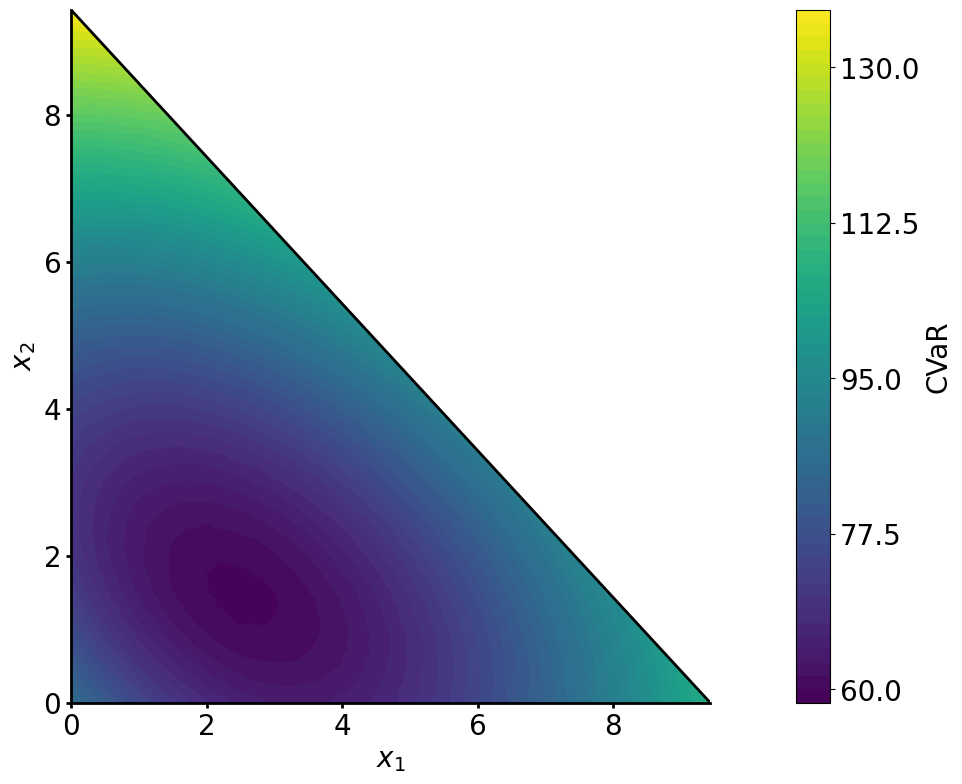

In [5]:

# Convert to numpy array
CVaR = np.array(cvar_column)

# Interpolate onto a regular grid
grid_CVaR = griddata((feasible_region[:, 0], feasible_region[:, 1]), CVaR, (W1, W2), method='cubic')

# Plot the filled contour map of expected return
plt.figure(figsize=(11, 9))
contour = plt.contourf(W1, W2, grid_CVaR, levels=50, cmap='viridis')

# Add heatmap colorbar
cbar = plt.colorbar(contour, pad=0.1,ticks=np.linspace(60,130,5))  # Reduce ticks
cbar.set_label('CVaR', fontsize=20)  # LaTeX formatted label
cbar.ax.tick_params(labelsize=20)

# Set axis labels (LaTeX formatted)
plt.xlabel(r'$x_1$', fontsize=20)
plt.ylabel(r'$x_2$', fontsize=20)

# Set tick font size
plt.tick_params(axis='both', which='major', labelsize=20, width=2)

# Bold the axis lines
ax = plt.gca()
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)

# Remove top and right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

x1_max=np.max(W1_data)
x2_max=np.max(W2_data)
plt.plot([0, x1_max], [x2_max, 0], 'k-', linewidth=2)  # Black diagonal line, assuming (0,1) to (1,0) is the triangle edge

plt.show()


In [6]:
def find_pareto_frontier(input_data):
    """
    Compute the Pareto frontier.
    
    Parameters:
    input_data -- input 2D numpy array, each row is a multi-objective data point
    
    Returns:
    membership -- boolean array indicating whether each point is on the Pareto frontier
    member_value -- the set of Pareto frontier points
    """
    # Initialize the list that stores Pareto frontier points
    pareto_frontier = []

    # Iterate over each data point
    for i in range(input_data.shape[0]):
        # Current data point
        c_data = np.tile(input_data[i, :], (input_data.shape[0], 1))
        # Copy the input data
        t_data = input_data.copy()
        # Mark the current point as infinity to exclude itself
        t_data[i, :] = np.inf

        # Check whether the current point is greater than or equal to other points in all dimensions
        smaller_idx = c_data >= t_data

        # If the current point is not dominated by any other point, add it to the Pareto frontier
        if not np.any(np.sum(smaller_idx, axis=1) == input_data.shape[1]):
            pareto_frontier.append(input_data[i, :])

    # Convert to numpy array
    pareto_frontier = np.array(pareto_frontier)

    # Generate the membership boolean array indicating whether each point is on the Pareto frontier
    membership = np.array([np.any(np.all(input_data[i] == pareto_frontier, axis=1)) for i in range(input_data.shape[0])])

    return membership, pareto_frontier

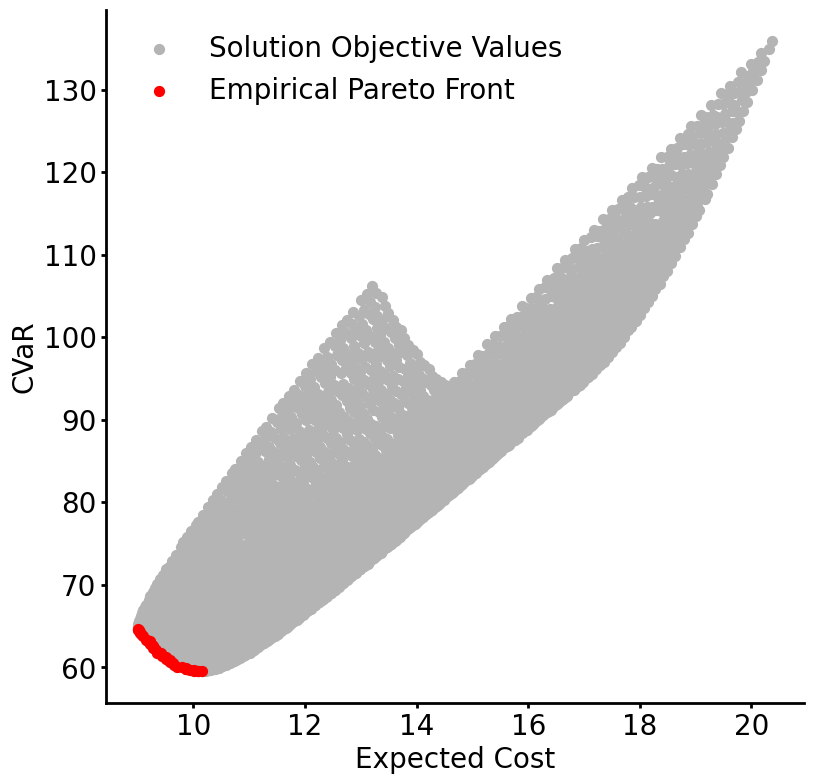

In [7]:
# Find the Pareto frontier
points = np.column_stack((expected_returns, CVaR))  # Combine expected_returns and CVaR into a point set
membership, pareto_frontier = find_pareto_frontier(points)  # Compute the Pareto frontier
# Plot the figure
plt.figure(figsize=(9, 9))

# Scatter plot, color set to a dull gray
plt.scatter(expected_returns, CVaR, s=50, color=color_3, label='Solution Objective Values')

# Pareto frontier points, red dots
plt.scatter(
    pareto_frontier[:, 0], pareto_frontier[:, 1], 
    color='red', edgecolor='red', s=50, label='Empirical Pareto Front'
)

# Set axis labels (LaTeX formatted)
plt.xlabel(r'Expected Cost', fontsize=20)
plt.ylabel(r'CVaR', fontsize=20)

# Increase tick font size
plt.tick_params(axis='both', which='major', labelsize=20, width=2)

# Bold the axis lines
ax = plt.gca()
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)

# Remove top and right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Remove the legend border
plt.legend(frameon=False, fontsize=20)

plt.show()


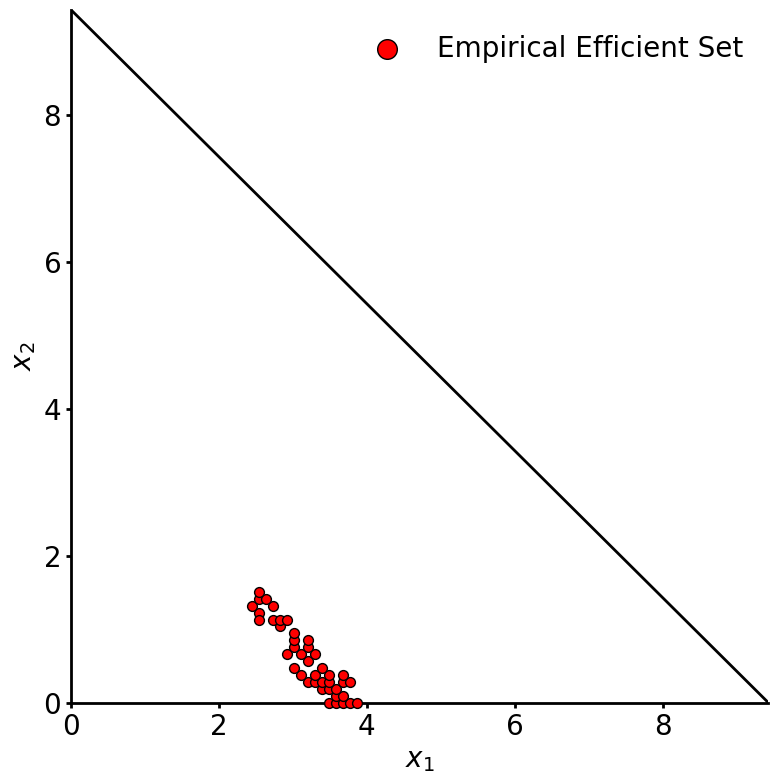

In [8]:

plt.figure(figsize=(9, 9))
# Annotate the solutions corresponding to the Pareto frontier on the plane plot
pareto_feasible_solutions = feasible_region[membership]  # Find the solutions corresponding to the Pareto frontier based on membership

# Plot the filled contour map of expected return

#contour = plt.contourf(W1, W2, grid_CVaR, levels=50, cmap='viridis')


# Set axis labels (LaTeX formatted)
plt.xlabel(r'$x_1$', fontsize=20)
plt.ylabel(r'$x_2$', fontsize=20)

# Set tick font size
plt.tick_params(axis='both', which='major', labelsize=20, width=2)

# Bold the axis lines
ax = plt.gca()
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)

# Remove top and right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

x1_max=np.max(W1_data)
x2_max=np.max(W2_data)
plt.xlim(0, x1_max)
plt.ylim(0, x2_max)
plt.plot([0, x1_max], [x2_max, 0], 'k-', linewidth=2)  # Black diagonal line, assuming (0,1) to (1,0) is the triangle edge
plt.scatter(pareto_feasible_solutions[:, 0], pareto_feasible_solutions[:, 1], color='r', s=50, label='Empirical Efficient Set', edgecolor='black',zorder=10,clip_on=False)
plt.legend(fontsize=20,frameon=False,markerscale=2) 

plt.show()


In [9]:
LB_list=np.load('LB_list_R1.npy')
UB_list=np.load('UB_list_R1.npy')
experimental_set=np.load('experimental_set_R1.npy')

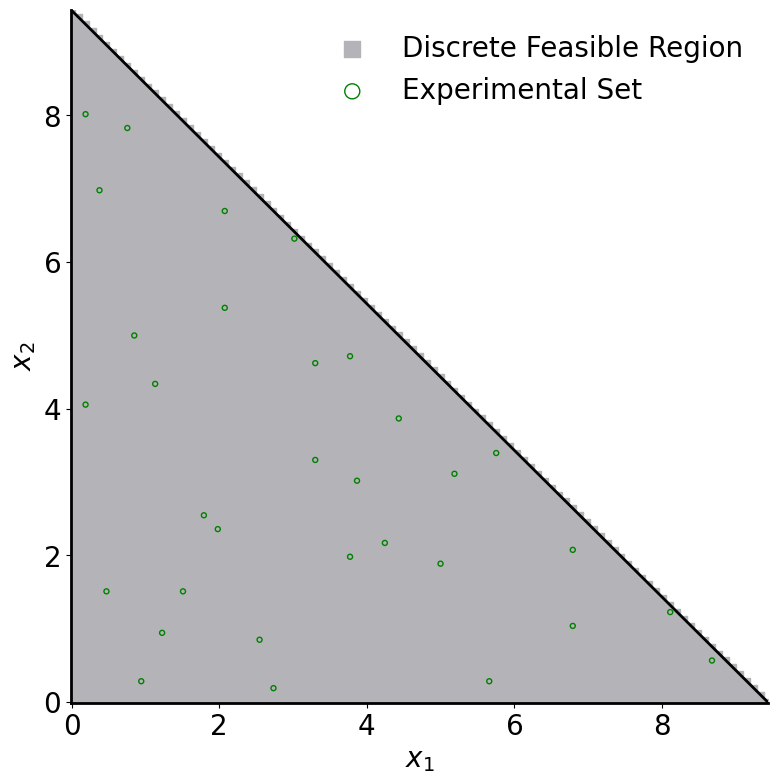

Number of feasible points: 5151


In [10]:
# Create the grid of w1 and w2
n_points = 101  # Number of points in the grid
w1_values = np.linspace(0, x1_max, n_points)
w2_values = np.linspace(0, x2_max, n_points)
W1, W2 = np.meshgrid(w1_values, w2_values)

# Convert grid points into a 1D array
points = np.vstack([W1.ravel(), W2.ravel()]).T

# Filter out points satisfying w1 + w2 <= 1
discrete_feasible_region = points[np.sum(points, axis=1) <= x1_max+0.001]


# Visualize the generated points
plt.figure(figsize=(9, 9))

# Plot the points of the discrete feasible region (gray)
plt.scatter(discrete_feasible_region[:, 0], discrete_feasible_region[:, 1], 
            color="#B4B4B8", s=13, label='Discrete Feasible Region',marker='s')

# Plot the experimental point set (green, black border)
plt.scatter(experimental_set[:, 0], experimental_set[:, 1], 
            s=13, facecolor='none', edgecolors='green', label='Experimental Set')

# Set axis labels (LaTeX formatted)
plt.xlabel(r'$x_1$', fontsize=20)
plt.ylabel(r'$x_2$', fontsize=20)

# Increase tick font size
plt.tick_params(axis='both', which='major', labelsize=20)

# Bold the axis lines
ax = plt.gca()
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)

# Remove top and right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add legend and adjust its position
plt.legend(frameon=False, fontsize=20,markerscale=3)
x1_max=np.max(W1_data)
x2_max=np.max(W2_data)
plt.xlim(-0.01, x1_max+0.01)  # Set the x-axis range to [0, 1]
plt.ylim(-0.01, x2_max+0.01)  # Set the y-axis range to [0, 1]
plt.plot([-0.01, x1_max+0.25], [x2_max+0.01, -0.25], 'k-', linewidth=2)  # Black diagonal line, assuming (0,1) to (1,0) is the triangle edge
# Show the figure
plt.show()

# Print the number of feasible points
num_to_check = len(discrete_feasible_region)
print(f"Number of feasible points: {num_to_check}")


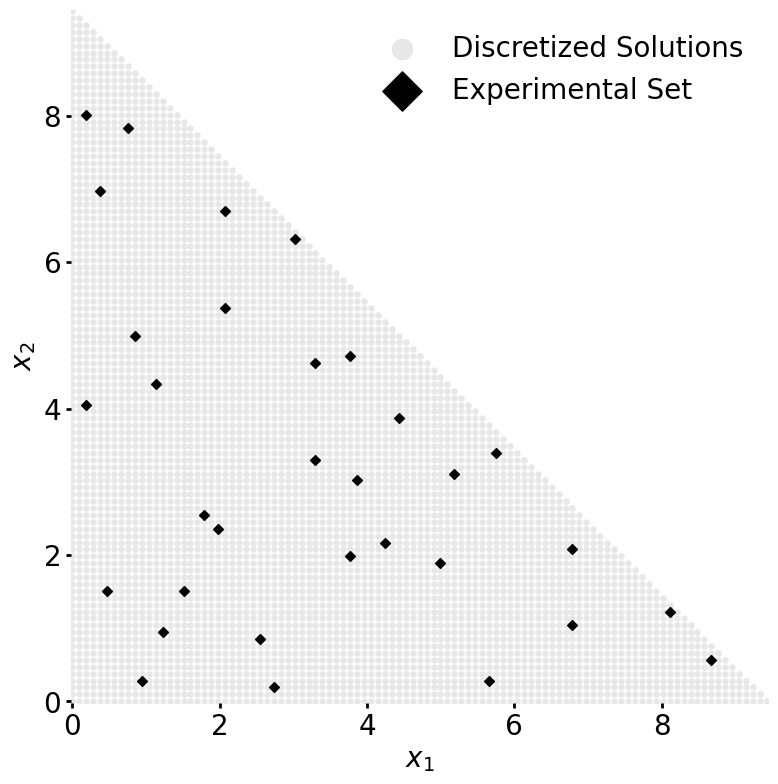

Number of feasible points: 5151


In [11]:

# Create the grid of w1 and w2
n_points = 101  # Number of points in the grid
w1_values = np.linspace(0, x1_max, n_points)
w2_values = np.linspace(0, x2_max, n_points)
W1, W2 = np.meshgrid(w1_values, w2_values)

points = np.vstack([W1.ravel(), W2.ravel()]).T

# Filter out points satisfying w1 + w2 <= 1
discrete_feasible_region = points[np.sum(points, axis=1) <= x1_max+0.001]


# Visualize the generated points
plt.figure(figsize=(9, 9))

# Plot the points of the discrete feasible region (gray)
plt.scatter(discrete_feasible_region[:, 0], discrete_feasible_region[:, 1], 
            color=color_0, s=13, label='Discretized Solutions')

# Plot the experimental point set (green, black border)
plt.scatter(experimental_set[:, 0], experimental_set[:, 1], 
            s=25, facecolor=color_2, edgecolors=color_2, label='Experimental Set',marker='D')

# Set axis labels (LaTeX formatted)
plt.xlabel(r'$x_1$', fontsize=20)
plt.ylabel(r'$x_2$', fontsize=20)

# Increase tick font size
plt.tick_params(axis='both', which='major', labelsize=20, width=2)

# Bold the axis lines
ax = plt.gca()
ax.spines['left'].set_linewidth(0)
ax.spines['bottom'].set_linewidth(0)

# Remove top and right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add legend and adjust its position
plt.legend(frameon=False, fontsize=20,markerscale=4)
x1_max=np.max(W1_data)
x2_max=np.max(W2_data)
plt.xlim(-0.02, x1_max+0.02)  # Set the x-axis range to [0, 1]
plt.ylim(-0.02, x2_max+0.02)  # Set the y-axis range to [0, 1]
#plt.plot([-0.01, 1.025], [1.025, -0.01], 'k-', linewidth=2)  # Black diagonal line, assuming (0,1) to (1,0) is the triangle edge
# Show the figure
triangle_coords = [
    (0, 1),
    (1, 1),
    (1, 0)
]
triangle = Polygon(triangle_coords, facecolor='white', edgecolor='none', linewidth=0.5, zorder=2)
#ax.add_patch(triangle)
plt.show()

# Print the number of feasible points
num_to_check = len(discrete_feasible_region)
print(f"Number of feasible points: {num_to_check}")


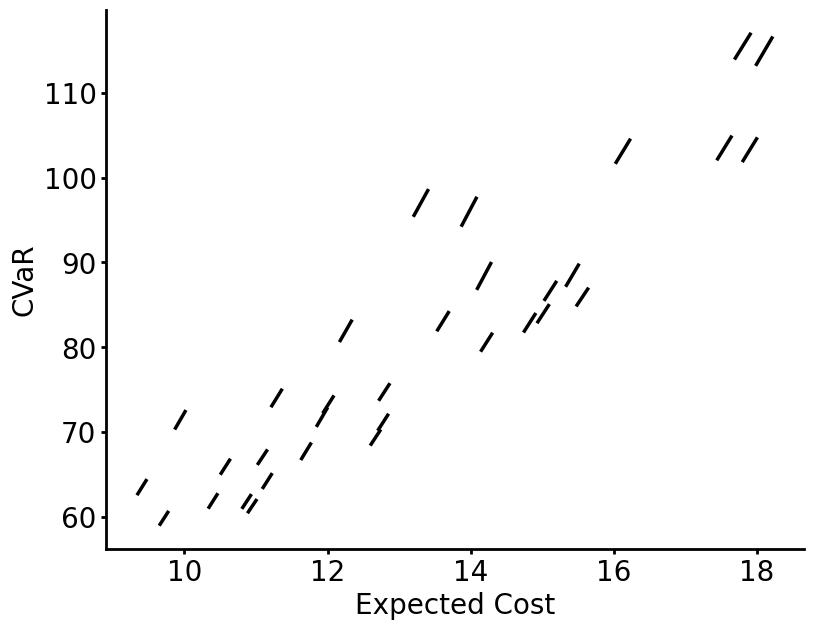

In [12]:

# Plot the figure
plt.figure(figsize=(9, 7))

for i in range(len(LB_list)):
    plt.plot([LB_list[i, 0], UB_list[i, 0]], [LB_list[i, 1], UB_list[i, 1]], 
             color='black', linestyle='-', linewidth=2.5)
    
plt.xlabel('Expected Cost', fontsize=20)
plt.ylabel('CVaR', fontsize=20)
plt.tick_params(axis='both', which='major', labelsize=20, width=2)

# Bold the axis lines
ax = plt.gca()
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
# Remove top and right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

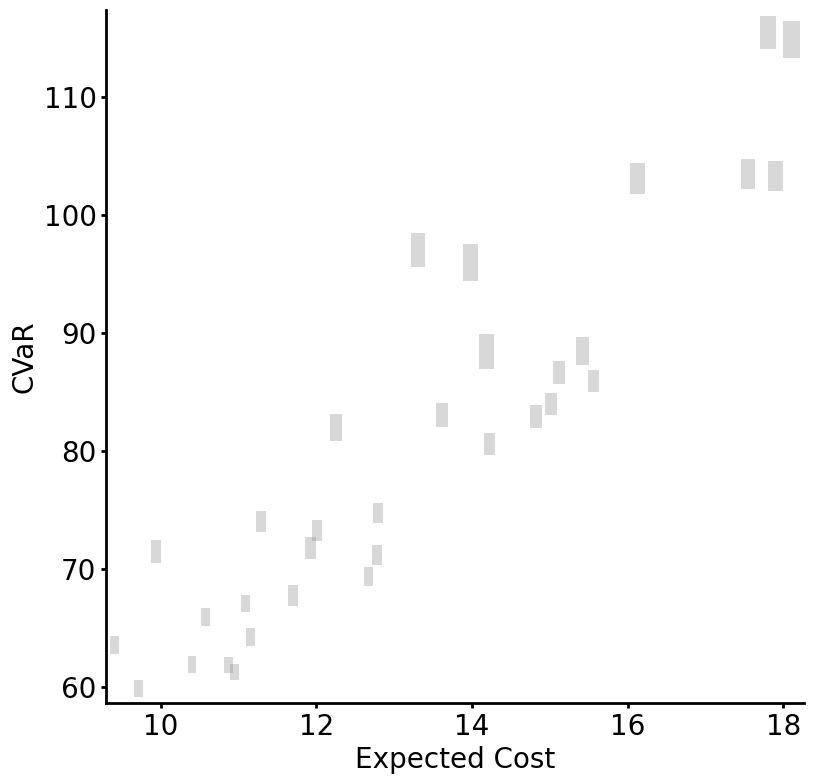

In [13]:
import matplotlib.patches as patches
plt.figure(figsize=(9, 9))
ax = plt.gca()

# Draw semi-transparent rectangles
for i in range(len(LB_list)):
    rect = patches.Rectangle(LB_list[i],  # Bottom-left corner coordinates
                             UB_list[i, 0] - LB_list[i, 0],  # Width
                             UB_list[i, 1] - LB_list[i, 1],  # Height
                             linewidth=0, edgecolor=None, 
                             facecolor='gray', alpha=0.3)  # Semi-transparent
    ax.add_patch(rect)

plt.xlabel('Expected Cost', fontsize=20)
plt.ylabel('CVaR', fontsize=20)
plt.tick_params(axis='both', which='major', labelsize=20, width=2)

# Bold the axis lines
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
# Remove top and right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Show the figure
plt.xlim(LB_list[:, 0].min() - 0.05, UB_list[:, 0].max() + 0.05)
plt.ylim(LB_list[:, 1].min() - 0.5, UB_list[:, 1].max() + 0.5)

plt.show()

In [14]:
# Read the actual w1, w2 data points from the CSV file
tail_quantile_demand=0.995
shape_demand=2.0
scale_demand=2.0
percentail_demand=stats.gamma.ppf(tail_quantile_demand, shape_demand, scale_demand)
w1_values = np.linspace(0, percentail_demand, 101)
w2_values = np.linspace(0, percentail_demand, 101)

# Generate feasible region
W1, W2 = np.meshgrid(w1_values, w2_values)
W3 = 1 - W1 - W2
weights = np.vstack([W1.ravel(), W2.ravel()]).T
feasible_region = weights[(weights >= 0).all(axis=1) & (weights.sum(axis=1) <=percentail_demand+0.001)]
print('the number of feasible region',len(feasible_region))
discrete_feasible_region = feasible_region[np.sum(feasible_region, axis=1) <= percentail_demand+0.001]

the number of feasible region 5151


In [15]:
discrete_inference=np.load('discrete_inference_convexity.npy')


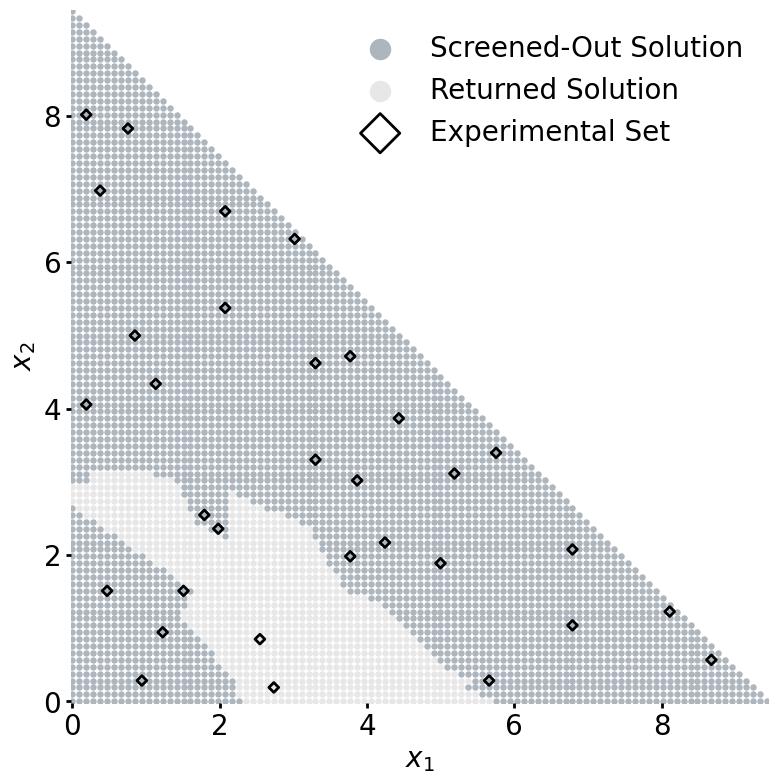

In [16]:
# Create a temporary variable, converting the list into an array for mask processing
discrete_inference_array = np.array(discrete_inference)

# Visualize the generated points
plt.figure(figsize=(9, 9))



# Use a boolean mask to filter and plot points of category 1
mask_1 = (discrete_inference_array == 1)
plt.scatter(discrete_feasible_region[mask_1, 0], 
            discrete_feasible_region[mask_1, 1], 
            c=color_1, s=13, label='Screened-Out Solution')


# Use a boolean mask to filter and plot points of category 0
mask_0 = (discrete_inference_array == 0)
plt.scatter(discrete_feasible_region[mask_0, 0], 
            discrete_feasible_region[mask_0, 1], 
            c=color_0, s=13, label='Returned Solution')

plt.scatter(experimental_set[:, 0], experimental_set[:, 1], 
            s=25, color='none', edgecolors=color_2, label='Experimental Set',linewidths=2,marker='D')

#plt.title('Solutions at Percentage Integer Lattice', fontsize=20)
# Bold the axis lines
ax = plt.gca()
ax.spines['left'].set_linewidth(0)
ax.spines['bottom'].set_linewidth(0)

# Remove top and right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add legend and adjust its position
plt.legend(frameon=False, fontsize=20)
plt.xlim(-0.02, percentail_demand+0.02)  # Set the x-axis range to [0, 1]
plt.ylim(-0.02, percentail_demand+0.02)  # Set the y-axis range to [0, 1]


# Set axis labels (LaTeX formatted)
plt.xlabel(r'$x_1$', fontsize=20)
plt.ylabel(r'$x_2$', fontsize=20)

# Increase tick font size
plt.tick_params(axis='both', which='major', labelsize=20, width=2)

# Show the legend
plt.legend(fontsize=20, frameon=False,facecolor='grey',markerscale=4)  # Set background color

plt.show()

In [17]:
print('The number of Screened-Out Pixels is',sum(discrete_inference) , '. The number of total solutions is',np.shape(discrete_feasible_region)[0])


The number of Screened-Out Pixels is 4250 . The number of total solutions is 5151


In [18]:
inference_time_convexity_discrete=np.load('inference_time_convexity_discrete.npy')
print(np.quantile(inference_time_convexity_discrete,0.90))
print(np.quantile(inference_time_convexity_discrete,0.50))
print(np.mean(inference_time_convexity_discrete))
print(np.max(inference_time_convexity_discrete))
print(sum(inference_time_convexity_discrete))

0.03397229199981666
0.0007299999997485429
0.00985158796542342
0.13871583299987833
50.74552960989604


In [19]:
inference_time_convexity_discrete=np.load('inference_time_convexity_discrete_missing.npy')
discrete_inference=np.load('discrete_inference_convexity_missing.npy')
print(np.quantile(inference_time_convexity_discrete,0.90))
print(np.quantile(inference_time_convexity_discrete,0.50))
print(np.mean(inference_time_convexity_discrete))
print(np.max(inference_time_convexity_discrete))
print(sum(inference_time_convexity_discrete))
print('The number of Screened-Out Pixels is',sum(discrete_inference) , '. The number of total solutions is',np.shape(discrete_feasible_region)[0])


0.011187583997525508
0.0007450000011886004
0.003465705307285919
0.05115020899756928
17.851848037829768
The number of Screened-Out Pixels is 4238 . The number of total solutions is 5151


In [20]:
inference_time_convexity_discrete=np.load('inference_time_convexity_discrete_relaxed.npy')
discrete_inference=np.load('discrete_inference_convexity_relaxed.npy')
print(np.quantile(inference_time_convexity_discrete,0.90))
print(np.quantile(inference_time_convexity_discrete,0.50))
print(np.mean(inference_time_convexity_discrete))
print(np.max(inference_time_convexity_discrete))
print(sum(inference_time_convexity_discrete))
print('The number of Screened-Out Pixels is',sum(discrete_inference) , '. The number of total solutions is',np.shape(discrete_feasible_region)[0])


0.008127500001137378
0.0004850830009672791
0.0026349864156609854
0.04491845800293959
13.572815027069737
The number of Screened-Out Pixels is 4250 . The number of total solutions is 5151


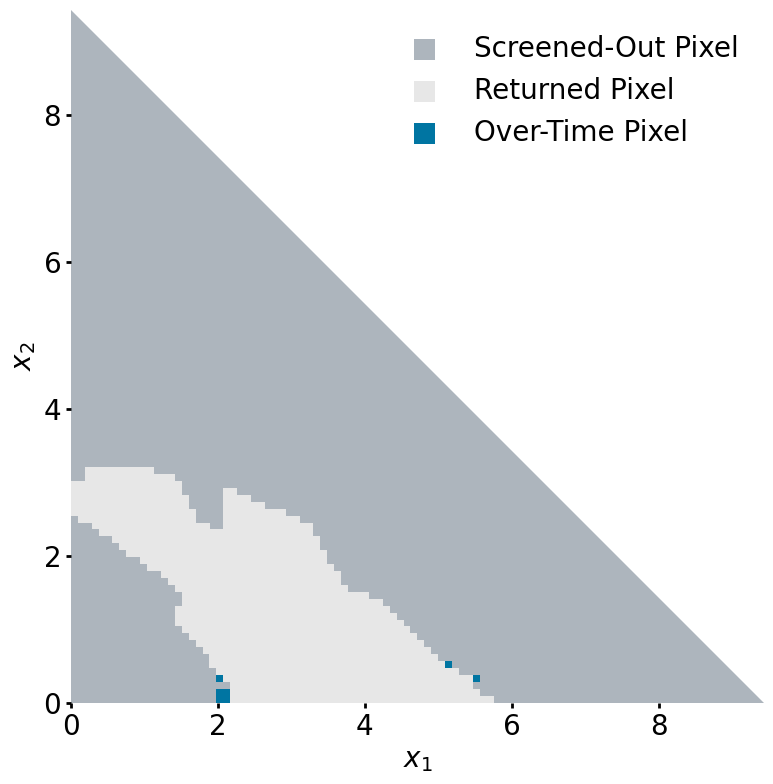

In [21]:
from matplotlib.patches import Polygon
import numpy as np
import matplotlib.pyplot as plt

# Read the ES_Confidence data
ES_Confidence = np.load('ES_Confidence.npy', allow_pickle=True)

# Ensure the values of ES_Confidence are of integer type
ES_Confidence = ES_Confidence.astype(int)
ES_Confidence = np.flip(ES_Confidence, axis=0)  # Flip along the vertical axis
ES_Confidence = np.rot90(ES_Confidence, k=3)  # Rotate

# Set parameters
resolution_1 = ES_Confidence.shape[0]  # Automatically get the resolution from the data
resolution_2 = ES_Confidence.shape[1]
scope1 = percentail_demand
scope2 = percentail_demand
start_point1 = 0
start_point2 = 0
step_size1 = scope1 / resolution_1
step_size2 = scope2 / resolution_2

# Generate the centers of the grid points
x = np.linspace(start_point1 + step_size1 / 2, scope1 - step_size1 / 2, resolution_1)
y = np.linspace(start_point2 + step_size2 / 2, scope2 - step_size2 / 2, resolution_2)
X, Y = np.meshgrid(x, y)

# Flatten the coordinate and color data
X_flat = X.ravel()
Y_flat = Y.ravel()
scatter_labels = ["Screened-Out Pixel", "Returned Pixel", "Over-Time Pixel"]
colors = np.array([ color_1,color_0,color_4])  # Define color order: 0-gray, 1-dark gray, 2-red, 3-blue

# Create the canvas
fig, ax = plt.subplots(figsize=(9, 9))

# Plot scatter plots of different categories and add a legend

mask_0 = ES_Confidence.ravel() == 0  # Filter out the data of the corresponding category
ax.scatter(X_flat[mask_0],Y_flat[mask_0],c=colors[0],s=25,edgecolor="none",marker="s",label=scatter_labels[0])
mask_1 = ES_Confidence.ravel() == 1  # Filter out the data of the corresponding category
ax.scatter(X_flat[mask_1],Y_flat[mask_1],c=colors[1],s=25,edgecolor="none",marker="s",label=scatter_labels[1])
mask_2 = ES_Confidence.ravel() == 3  # Filter out the data of the corresponding category
ax.scatter(X_flat[mask_2],Y_flat[mask_2],c=colors[2],s=25,edgecolor="none",marker="s",label=scatter_labels[2])


# Draw the triangle
triangle_coords = [
    (0, scope2),
    (scope1, scope2),
    (scope1, 0)
]
triangle = Polygon(triangle_coords, facecolor='white', edgecolor='white', linewidth=0, zorder=2)
ax.add_patch(triangle)

# Set the range of the x-axis and y-axis
ax.set_xlim(start_point1, start_point1 + scope1)
ax.set_ylim(start_point2, start_point2 + scope2)

# Set the x-axis and y-axis ticks to every 0.1
ticks = np.arange(start_point1, start_point1 + scope1 + 0.2, 2)
ax.set_xticks(ticks)
ax.set_yticks(ticks)

# Set labels
ax.set_xlabel(r'$x_1$', fontsize=20)
ax.set_ylabel(r'$x_2$', fontsize=20)

# Keep the aspect ratio consistent
ax.set_aspect('equal')
ax.tick_params(axis='both', which='major', labelsize=20, width=2)

# Bold the axis lines
ax.spines['left'].set_linewidth(0)
ax.spines['bottom'].set_linewidth(0)

# Add a black diagonal line
#plt.plot([0, 1], [1, 0], 'k-', linewidth=2)  # Black diagonal line, assuming (0,1) to (1,0) is the triangle edge

# Remove top and right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add legend
plt.legend(frameon=False, fontsize=20,markerscale=3,loc='upper right')

# Show the figure
plt.show()


In [22]:
resolution_1 = ES_Confidence.shape[0]  # Automatically get the resolution from the data
resolution_2 = ES_Confidence.shape[1]
scope1 = percentail_demand
scope2 = percentail_demand
start_point1 = 0
start_point2 = 0
step_size1 = scope1 / resolution_1
step_size2 = scope2 / resolution_2

print(step_size1)

0.09430129500280121


In [23]:
import numpy as np
ES_Confidence = np.load('ES_Confidence.npy', allow_pickle=True)
ES_time_stats=np.load('ES_time_stats.npy',allow_pickle=True)
ES_time_stats = np.array(ES_time_stats).reshape(100, 100)
inference_result=[]
time_result=[]
time_returned=[]
time_screened=[]
for i in range(100):
    for j in range(100-i):
        inference_result.append(ES_Confidence[i,j])
        time_result.append(ES_time_stats[j,i])
        if ES_Confidence[i,j]==0:
            time_screened.append(ES_time_stats[j,i])
        if ES_Confidence[i,j]==1:
            time_returned.append(ES_time_stats[j,i])
            
inference_result=np.array(inference_result)
np.shape(inference_result)
np.shape(time_result)
count_of_zeros = np.sum(inference_result == 0)
print('The number of Screened-Out Solutions is',count_of_zeros , '. The number of total solutions is',np.shape(inference_result)[0])
count_of_ones = np.sum(inference_result == 1)
print('The number of returned solutions is',count_of_ones , '. The number of total solutions is',np.shape(inference_result)[0])
count_of_ts = np.sum(inference_result == 3)
print('The number of OT solutions is',count_of_ts , '. The number of total solutions is',np.shape(inference_result)[0])


print(np.quantile(time_result,0.90))
print(np.quantile(time_result,0.50))
print(np.mean(time_result))
print(np.max(time_result))
print(np.mean(time_result))
print(sum(time_result))
for i in range(len(time_result)):
    if time_result[i]>90:
        time_result[i]=90

print(sum(time_result))
print(len(time_result))

The number of Screened-Out Solutions is 4077 . The number of total solutions is 5050
The number of returned solutions is 966 . The number of total solutions is 5050
The number of OT solutions is 7 . The number of total solutions is 5050
1.0360276827000066
0.18359549999999558
0.5595383074920794
90.09319058300002
0.5595383074920794
2825.6684528349906
2825.4090468759905
5050


In [24]:
ES_Confidence = np.load('ES_Confidence_M.npy', allow_pickle=True)
ES_time_stats=np.load('ES_time_stats_M.npy',allow_pickle=True)
inference_result=[]
time_result=[]
time_returned=[]
time_screened=[]
for i in range(100):
    for j in range(100-i):
        inference_result.append(ES_Confidence[i,j])
        time_result.append(ES_time_stats[j,i])
        if ES_Confidence[i,j]==0:
            time_screened.append(ES_time_stats[j,i])
        if ES_Confidence[i,j]==1:
            time_returned.append(ES_time_stats[j,i])
            
inference_result=np.array(inference_result)
np.shape(inference_result)
np.shape(time_result)
count_of_zeros = np.sum(inference_result == 0)
print('The number of Screened-Out Solutions is',count_of_zeros , '. The number of total solutions is',np.shape(inference_result)[0])
count_of_ones = np.sum(inference_result == 1)
print('The number of returned solutions is',count_of_ones , '. The number of total solutions is',np.shape(inference_result)[0])
count_of_ts = np.sum(inference_result == 3)
print('The number of OT solutions is',count_of_ts , '. The number of total solutions is',np.shape(inference_result)[0])

print(np.quantile(time_result,0.90))
print(np.quantile(time_result,0.50))
print(np.mean(time_result))
print(np.max(time_result))
print(np.mean(time_result))
print(sum(time_result))
for i in range(len(time_result)):
    if time_result[i]>90:
        time_result[i]=90

print(sum(time_result))
print(len(time_result))

The number of Screened-Out Solutions is 4072 . The number of total solutions is 5050
The number of returned solutions is 978 . The number of total solutions is 5050
The number of OT solutions is 0 . The number of total solutions is 5050
0.20784021700000055
0.10423391649999303
0.09548561753762497
1.5173398750000615
0.09548561753762497
482.20236856500605
482.20236856500605
5050


In [25]:
ES_Confidence = np.load('ES_Confidence_relaxed.npy', allow_pickle=True)
ES_time_stats=np.load('ES_time_stats_relaxed.npy',allow_pickle=True)
inference_result=[]
time_result=[]
time_returned=[]
time_screened=[]
for i in range(100):
    for j in range(100-i):
        inference_result.append(ES_Confidence[i,j])
        time_result.append(ES_time_stats[j,i])
        if ES_Confidence[i,j]==0:
            time_screened.append(ES_time_stats[j,i])
        if ES_Confidence[i,j]==1:
            time_returned.append(ES_time_stats[j,i])
            
inference_result=np.array(inference_result)
np.shape(inference_result)
np.shape(time_result)
count_of_zeros = np.sum(inference_result == 0)
print('The number of Screened-Out Solutions is',count_of_zeros , '. The number of total solutions is',np.shape(inference_result)[0])
count_of_ones = np.sum(inference_result == 1)
print('The number of returned solutions is',count_of_ones , '. The number of total solutions is',np.shape(inference_result)[0])
count_of_ts = np.sum(inference_result == 3)
print('The number of OT solutions is',count_of_ts , '. The number of total solutions is',np.shape(inference_result)[0])

print(np.quantile(time_result,0.90))
print(np.quantile(time_result,0.50))
print(np.mean(time_result))
print(np.max(time_result))
print(np.mean(time_result))
print(sum(time_result))
for i in range(len(time_result)):
    if time_result[i]>90:
        time_result[i]=90

print(sum(time_result))
print(len(time_result))

The number of Screened-Out Solutions is 4080 . The number of total solutions is 5050
The number of returned solutions is 966 . The number of total solutions is 5050
The number of OT solutions is 4 . The number of total solutions is 5050
0.23292296670017554
0.0306343749999769
0.20210225034197715
90.01151541599984
0.20210225034197715
1020.6163642269846
1020.5895585609849
5050


In [26]:
PF_Confidence_convexity=np.load('PF_Confidence.npy',allow_pickle=True)
np.shape(PF_Confidence_convexity)


(24, 45)

/var/folders/c9/6qmb3v514n75wd95b3hh4kv00000gn/T/ipykernel_62329/911621516.py:22: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle(
/var/folders/c9/6qmb3v514n75wd95b3hh4kv00000gn/T/ipykernel_62329/911621516.py:30: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle(
/var/folders/c9/6qmb3v514n75wd95b3hh4kv00000gn/T/ipykernel_62329/911621516.py:50: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle(


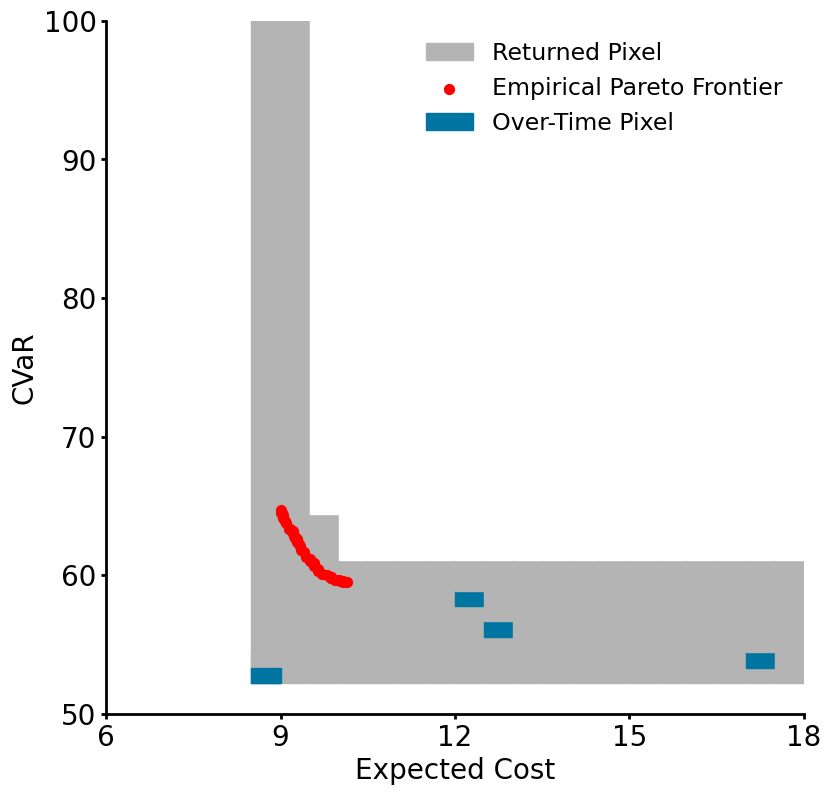

In [27]:
PF_Confidence_convexity=np.load('PF_Confidence.npy',allow_pickle=True)

resolution_1=24
resolution_2=45
scope1=12
scope2=50
step_size1=scope1/resolution_1
step_size2=scope2/resolution_2
start_point1=6
start_point2=50


# Create the canvas
fig, ax = plt.subplots(figsize=(9, 9))

# Draw the rectangular blocks in the grid
colors = ['white', color_3, 'red',color_4]

for i in range(resolution_1):
    for j in range(resolution_2):
        color_value = colors[PF_Confidence_convexity[i, j]]
        ax.add_patch(plt.Rectangle(
            (start_point1 + i * step_size1, start_point2 + j * step_size2),
            step_size1, step_size2, color=color_value, edgecolor='none'
        ))

found_indices = np.argwhere(PF_Confidence_convexity == 1)
i=found_indices[0][0]
j=found_indices[0][1]
ax.add_patch(plt.Rectangle(
            (start_point1 + i * step_size1, start_point2 + j * step_size2),
            step_size1, step_size2, color=colors[1], edgecolor='none',label='Returned Pixel'
        ))




# # Draw the upper and lower bounds
# for i in range(len(LB_list)):
#     ax.plot([LB_list[i, 0], UB_list[i, 0]], [LB_list[i, 1], UB_list[i, 1]], 
#             color='black', linestyle='-', linewidth=2.5)

# Draw the Pareto Frontier
ax.scatter(pareto_frontier[:, 0], pareto_frontier[:, 1], 
           color='red', label='Empirical Pareto Frontier', s=50,zorder=3)

found_indices = np.argwhere(PF_Confidence_convexity == 3)
i=found_indices[0][0]
j=found_indices[0][1]
ax.add_patch(plt.Rectangle(
            (start_point1 + i * step_size1, start_point2 + j * step_size2),
            step_size1, step_size2, color=colors[3], edgecolor='none',label='Over-Time Pixel'
        ))

# Set the coordinate range
ax.set_xlim(start_point1, start_point1 + scope1)
ax.set_ylim(start_point2, start_point2 + scope2)

# Set grid lines and ticks
minor_xticks = np.arange(start_point1, start_point1 + scope1, step_size1)
minor_yticks = np.arange(start_point2, start_point2 + scope2, step_size2)
major_xticks = np.arange(start_point1, start_point1 + scope1 +0.1, 3)
major_yticks = np.arange(start_point2, start_point2 + scope2 + 5, 10)

ax.set_xticks(major_xticks)
ax.set_yticks(major_yticks)
ax.set_xticks(minor_xticks, minor=True)
ax.set_yticks(minor_yticks, minor=True)


# Set axis labels
ax.set_xlabel(r'Expected Cost', fontsize=20)
ax.set_ylabel(r'CVaR', fontsize=20)

# Remove top and right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# Bold the axis lines
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
# Set tick font size
ax.tick_params(axis='both', which='major', labelsize=20, width=2)
ax.tick_params(axis='both', which='minor', labelsize=20, width=0)
# Add legend
ax.legend(frameon=False, fontsize=17,loc='upper right')

# Show the figure
plt.show()


In [28]:
resolution_1=24
resolution_2=45
scope1=12
scope2=50
step_size1=scope1/resolution_1
step_size2=scope2/resolution_2
start_point1=6
start_point2=50

print(step_size1)
print(step_size2)

0.5
1.1111111111111112


In [29]:
PF_Confidence_convexity=np.load('PF_Confidence.npy',allow_pickle=True)
PF_time_stats_convexity=np.load('PF_time_stats.npy',allow_pickle=True)

print(sum(PF_Confidence_convexity.ravel()==0))
print('the number of screened-out pixels is',sum(PF_Confidence_convexity.ravel()==0))
print(sum(PF_Confidence_convexity.ravel()==1))
print('the number of returned pixels is',sum(PF_Confidence_convexity.ravel()==1))
print(sum(PF_Confidence_convexity.ravel()==3))
print('the number of over-time pixels is',sum(PF_Confidence_convexity.ravel()==3))

print(np.quantile(PF_time_stats_convexity,0.90))
print(np.quantile(PF_time_stats_convexity,0.50))
print(np.mean(PF_time_stats_convexity))
print(np.max(PF_time_stats_convexity))
print(sum(sum(PF_time_stats_convexity)))
PF_time_stats_convexity=PF_time_stats_convexity.ravel()
for i in range(len(PF_time_stats_convexity)):
    if PF_time_stats_convexity[i]>90:
        PF_time_stats_convexity[i]=90
print(sum(PF_time_stats_convexity))

855
the number of screened-out pixels is 855
221
the number of returned pixels is 221
4
the number of over-time pixels is 4
2.0227134788002337
0.0019190419998267316
1.0548766086703676
90.17567354099992
1139.266737363997
1138.9681553639975


In [30]:
PF_Confidence_convexity=np.load('PF_Confidence_M.npy',allow_pickle=True)
PF_time_stats_convexity=np.load('PF_time_stats_M.npy',allow_pickle=True)

print(sum(PF_Confidence_convexity.ravel()==0))
print('the number of screened-out pixels is',sum(PF_Confidence_convexity.ravel()==0))
print(sum(PF_Confidence_convexity.ravel()==1))
print('the number of returned pixels is',sum(PF_Confidence_convexity.ravel()==1))
print(sum(PF_Confidence_convexity.ravel()==3))
print('the number of over-time pixels is',sum(PF_Confidence_convexity.ravel()==3))

print(np.quantile(PF_time_stats_convexity,0.90))
print(np.quantile(PF_time_stats_convexity,0.50))
print(np.mean(PF_time_stats_convexity))
print(np.max(PF_time_stats_convexity))
print(sum(sum(PF_time_stats_convexity)))
PF_time_stats_convexity=PF_time_stats_convexity.ravel()
for i in range(len(PF_time_stats_convexity)):
    if PF_time_stats_convexity[i]>90:
        PF_time_stats_convexity[i]=90
print(sum(PF_time_stats_convexity))

855
the number of screened-out pixels is 855
222
the number of returned pixels is 222
3
the number of over-time pixels is 3
2.008292283299761
0.002294062499913707
0.8237842825425947
90.04094008399989
889.6870251460023
889.6174463120024


In [31]:
PF_Confidence_convexity=np.load('PF_Confidence_relaxed.npy',allow_pickle=True)
PF_time_stats_convexity=np.load('PF_time_stats_relaxed.npy',allow_pickle=True)

print(sum(PF_Confidence_convexity.ravel()==0))
print('the number of screened-out pixels is',sum(PF_Confidence_convexity.ravel()==0))
print(sum(PF_Confidence_convexity.ravel()==1))
print('the number of returned pixels is',sum(PF_Confidence_convexity.ravel()==1))
print(sum(PF_Confidence_convexity.ravel()==3))
print('the number of over-time pixels is',sum(PF_Confidence_convexity.ravel()==3))

print(np.quantile(PF_time_stats_convexity,0.90))
print(np.quantile(PF_time_stats_convexity,0.50))
print(np.mean(PF_time_stats_convexity))
print(np.max(PF_time_stats_convexity))
print(sum(sum(PF_time_stats_convexity)))
PF_time_stats_convexity=PF_time_stats_convexity.ravel()
for i in range(len(PF_time_stats_convexity)):
    if PF_time_stats_convexity[i]>90:
        PF_time_stats_convexity[i]=90
print(sum(PF_time_stats_convexity))

855
the number of screened-out pixels is 855
220
the number of returned pixels is 220
5
the number of over-time pixels is 5
1.0063446954996835
0.0009570209999765211
0.738514641651868
90.05157458299982
797.5958129840174
797.4926137760185


In [32]:
discrete_inference_convexity=np.load('discrete_inference_convexity.npy')
discrete_inference_convexity_missing=np.load('discrete_inference_convexity_missing.npy')

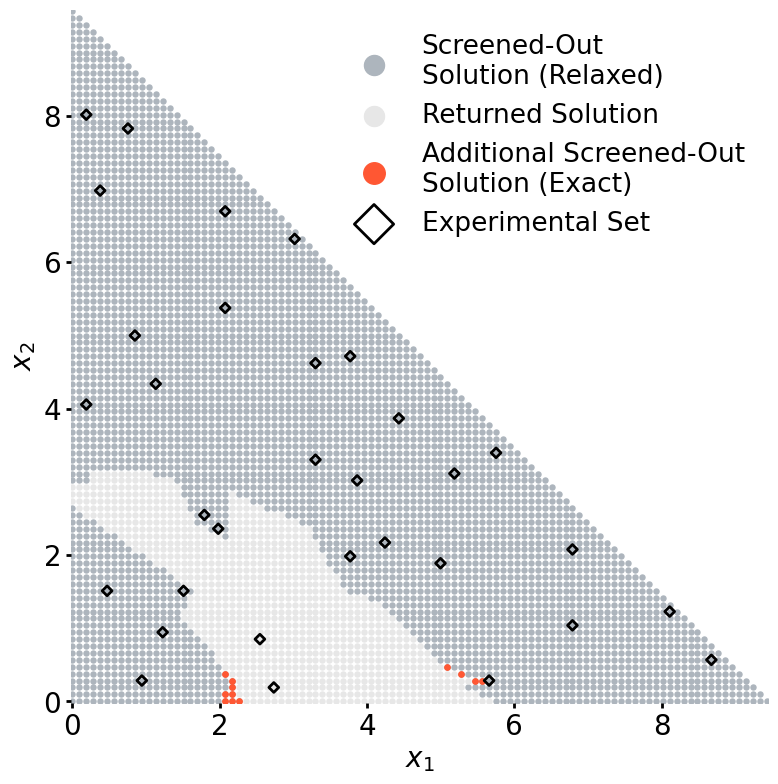

In [33]:
# Create a temporary variable, converting the list into an array for mask processing
discrete_inference_array_C = np.array(discrete_inference_convexity)
discrete_inference_array_CM = np.array(discrete_inference_convexity_missing)

# Visualize the generated points
plt.figure(figsize=(9, 9))


# Use a boolean mask to filter and plot points of category 1
mask_1 = (discrete_inference_array == 1)
plt.scatter(discrete_feasible_region[mask_1, 0], 
            discrete_feasible_region[mask_1, 1], 
            c=color_1, s=13, label='Screened-Out\nSolution (Relaxed)')


# Use a boolean mask to filter and plot points of category 0
mask_0 = (discrete_inference_array == 0)
plt.scatter(discrete_feasible_region[mask_0, 0], 
            discrete_feasible_region[mask_0, 1], 
            c=color_0, s=13, label='Returned Solution')



mask_2 = (discrete_inference_array_CM == 0) & (discrete_inference_array_C ==1)

plt.scatter(discrete_feasible_region[mask_2, 0], 
            discrete_feasible_region[mask_2, 1], 
            c='#FF5733', s=15, label='Additional Screened-Out\nSolution (Exact)')

plt.scatter(experimental_set[:, 0], experimental_set[:, 1], 
            s=25, color='none', edgecolors=color_2, label='Experimental Set',linewidths=2,marker='D')

#plt.title('Solutions at Percentage Integer Lattice', fontsize=20)
# Bold the axis lines
ax = plt.gca()
ax.spines['left'].set_linewidth(0)
ax.spines['bottom'].set_linewidth(0)

# Remove top and right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add legend and adjust its position
plt.legend(frameon=False, fontsize=20)
plt.xlim(-0.02, percentail_demand+0.02)  # Set the x-axis range to [0, 1]
plt.ylim(-0.02, percentail_demand+0.02)  # Set the y-axis range to [0, 1]


# Set axis labels (LaTeX formatted)
plt.xlabel(r'$x_1$', fontsize=20)
plt.ylabel(r'$x_2$', fontsize=20)

# Increase tick font size
plt.tick_params(axis='both', which='major', labelsize=20, width=2)

# Show the legend
plt.legend(fontsize=19, frameon=False,facecolor='lightgrey', markerscale=4 )  # Set background color

plt.show()

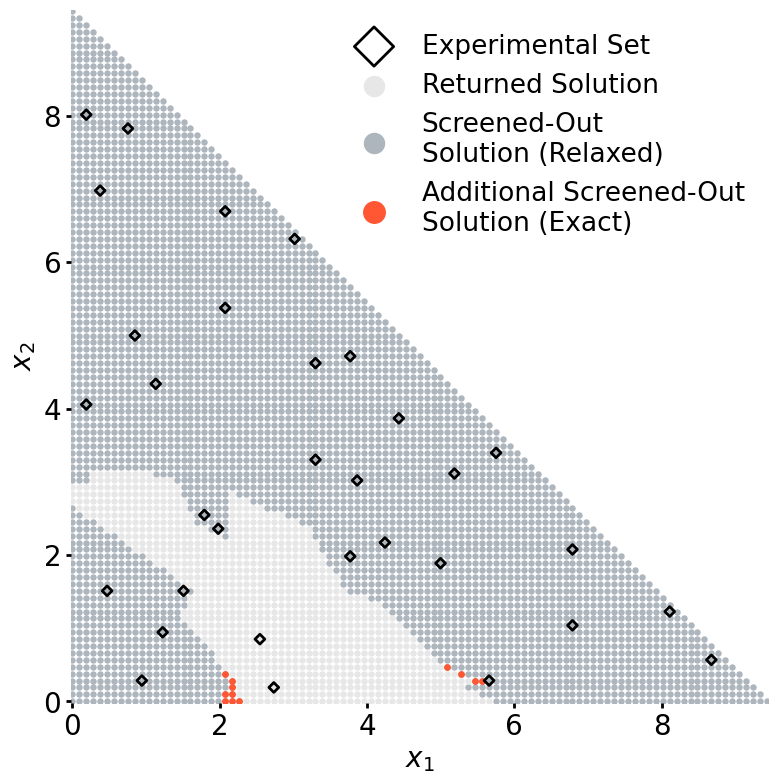

In [34]:
# Create a temporary variable, converting the list into an array for mask processing
discrete_inference_array_C = np.array(discrete_inference_convexity)
discrete_inference_array_CM = np.array(discrete_inference_convexity_missing)

# Visualize the generated points
plt.figure(figsize=(9, 9))

# Use a boolean mask to filter and plot points of category 1
mask_1 = (discrete_inference_array == 1)
scatter1 = plt.scatter(discrete_feasible_region[mask_1, 0], 
                        discrete_feasible_region[mask_1, 1], 
                        c=color_1, s=13, label='Screened-Out\nSolution (Relaxed)')

# Use a boolean mask to filter and plot points of category 0
mask_0 = (discrete_inference_array == 0)
scatter2 = plt.scatter(discrete_feasible_region[mask_0, 0], 
                        discrete_feasible_region[mask_0, 1], 
                        c=color_0, s=13, label='Returned Solution')

mask_2 = (discrete_inference_array_CM == 0) & (discrete_inference_array_C == 1)
scatter3 = plt.scatter(discrete_feasible_region[mask_2, 0], 
                        discrete_feasible_region[mask_2, 1], 
                        c='#FF5733', s=15, label='Additional Screened-Out\nSolution (Exact)')

scatter4 = plt.scatter(experimental_set[:, 0], experimental_set[:, 1], 
                        s=25, color='none', edgecolors=color_2, 
                        label='Experimental Set', linewidths=2, marker='D')

# Bold the axis lines
ax = plt.gca()
ax.spines['left'].set_linewidth(0)
ax.spines['bottom'].set_linewidth(0)

# Remove top and right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Customize legend order (4, 2, 1, 3)
handles = [scatter4, scatter2, scatter1, scatter3]  
labels = ['Experimental Set', 'Returned Solution', 
          'Screened-Out\nSolution (Relaxed)', 
          'Additional Screened-Out\nSolution (Exact)']

# Add legend
plt.legend(handles, labels, fontsize=19, frameon=False, facecolor='lightgrey', markerscale=4)

plt.xlim(-0.02, percentail_demand+0.02)  # Set the x-axis range
plt.ylim(-0.02, percentail_demand+0.02)  # Set the y-axis range

# Set axis labels (LaTeX formatted)
plt.xlabel(r'$x_1$', fontsize=20)
plt.ylabel(r'$x_2$', fontsize=20)

# Increase tick font size
plt.tick_params(axis='both', which='major', labelsize=20, width=2)

plt.show()


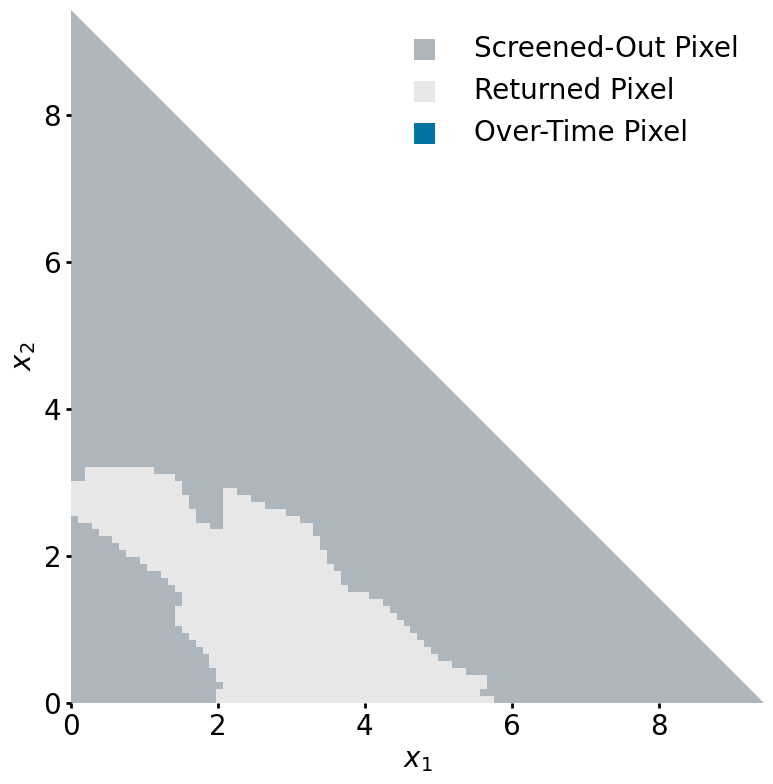

In [35]:
from matplotlib.patches import Polygon
import numpy as np
import matplotlib.pyplot as plt

# Read the ES_Confidence data
ES_Confidence = np.load('ES_Confidence_M.npy', allow_pickle=True)

# Ensure the values of ES_Confidence are of integer type
ES_Confidence = ES_Confidence.astype(int)
ES_Confidence = np.flip(ES_Confidence, axis=0)  # Flip along the vertical axis
ES_Confidence = np.rot90(ES_Confidence, k=3)  # Rotate

# Set parameters
resolution_1 = ES_Confidence.shape[0]  # Automatically get the resolution from the data
resolution_2 = ES_Confidence.shape[1]
scope1 = percentail_demand
scope2 = percentail_demand
start_point1 = 0
start_point2 = 0
step_size1 = scope1 / resolution_1
step_size2 = scope2 / resolution_2

# Generate the centers of the grid points
x = np.linspace(start_point1 + step_size1 / 2, scope1 - step_size1 / 2, resolution_1)
y = np.linspace(start_point2 + step_size2 / 2, scope2 - step_size2 / 2, resolution_2)
X, Y = np.meshgrid(x, y)

# Flatten the coordinate and color data
X_flat = X.ravel()
Y_flat = Y.ravel()
scatter_labels = ["Screened-Out Pixel", "Returned Pixel", "Over-Time Pixel"]
colors = np.array([ color_1,color_0,color_4])  # Define color order: 0-gray, 1-dark gray, 2-red, 3-blue

# Create the canvas
fig, ax = plt.subplots(figsize=(9, 9))

# Plot scatter plots of different categories and add a legend

mask_0 = ES_Confidence.ravel() == 0  # Filter out the data of the corresponding category
ax.scatter(X_flat[mask_0],Y_flat[mask_0],c=colors[0],s=25,edgecolor="none",marker="s",label=scatter_labels[0])
mask_1 = ES_Confidence.ravel() == 1  # Filter out the data of the corresponding category
ax.scatter(X_flat[mask_1],Y_flat[mask_1],c=colors[1],s=25,edgecolor="none",marker="s",label=scatter_labels[1])
mask_2 = ES_Confidence.ravel() == 3  # Filter out the data of the corresponding category
ax.scatter(X_flat[mask_2],Y_flat[mask_2],c=colors[2],s=25,edgecolor="none",marker="s",label=scatter_labels[2])


# Draw the triangle
triangle_coords = [
    (0, scope2),
    (scope1, scope2),
    (scope1, 0)
]
triangle = Polygon(triangle_coords, facecolor='white', edgecolor='white', linewidth=0, zorder=2)
ax.add_patch(triangle)

# Set the range of the x-axis and y-axis
ax.set_xlim(start_point1, start_point1 + scope1)
ax.set_ylim(start_point2, start_point2 + scope2)

# Set the x-axis and y-axis ticks to every 0.1
ticks = np.arange(start_point1, start_point1 + scope1 + 0.2, 2)
ax.set_xticks(ticks)
ax.set_yticks(ticks)

# Set labels
ax.set_xlabel(r'$x_1$', fontsize=20)
ax.set_ylabel(r'$x_2$', fontsize=20)

# Keep the aspect ratio consistent
ax.set_aspect('equal')
ax.tick_params(axis='both', which='major', labelsize=20, width=2)

# Bold the axis lines
ax.spines['left'].set_linewidth(0)
ax.spines['bottom'].set_linewidth(0)

# Add a black diagonal line
#plt.plot([0, 1], [1, 0], 'k-', linewidth=2)  # Black diagonal line, assuming (0,1) to (1,0) is the triangle edge

# Remove top and right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add legend
plt.legend(frameon=False, fontsize=20,markerscale=3,loc='upper right')

# Show the figure
plt.show()


In [36]:
discrete_inference_Lip=np.load('discrete_inference_Lip.npy')

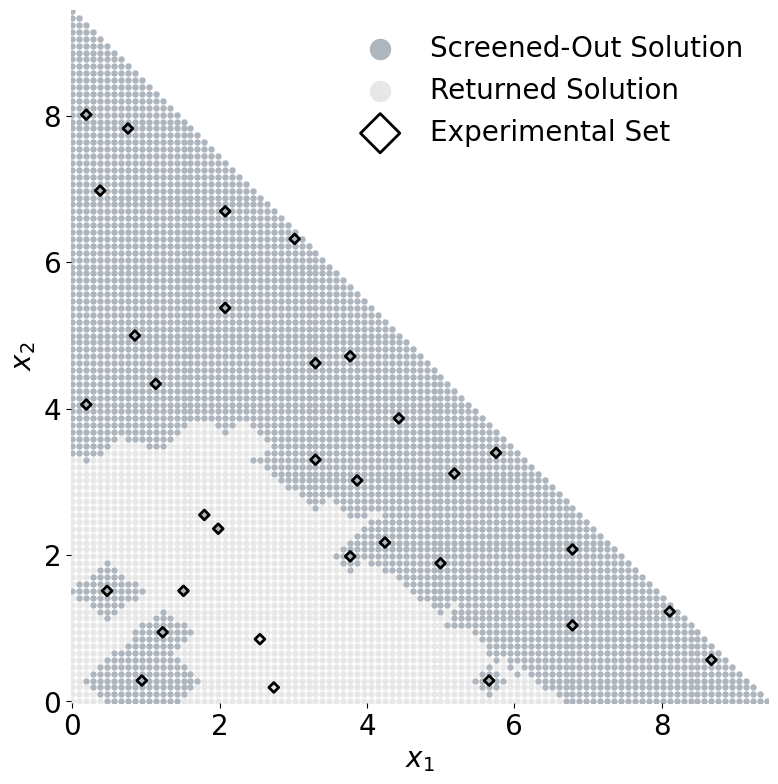

In [37]:
# Create a temporary variable, converting the list into an array for mask processing
discrete_inference_array = np.array(discrete_inference_Lip)

# Visualize the generated points
plt.figure(figsize=(9, 9))


# Use a boolean mask to filter and plot points of category 1
mask_1 = (discrete_inference_array == 1)
plt.scatter(discrete_feasible_region[mask_1, 0], 
            discrete_feasible_region[mask_1, 1], 
            c=color_1, s=13, label='Screened-Out Solution')


# Use a boolean mask to filter and plot points of category 0
mask_0 = (discrete_inference_array == 0)
plt.scatter(discrete_feasible_region[mask_0, 0], 
            discrete_feasible_region[mask_0, 1], 
            c=color_0, s=13, label='Returned Solution')

plt.scatter(experimental_set[:, 0], experimental_set[:, 1], 
            s=25, color='none', edgecolors=color_2, label='Experimental Set',linewidths=2,marker='D')

#plt.title('Solutions at Percentage Integer Lattice', fontsize=20)
# Bold the axis lines
ax = plt.gca()
ax.spines['left'].set_linewidth(0)
ax.spines['bottom'].set_linewidth(0)

# Remove top and right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add legend and adjust its position
plt.legend(frameon=False, fontsize=20)
plt.xlim(-0.02, x1_max+0.02)  # Set the x-axis range to [0, 1]
plt.ylim(-0.02, x2_max+0.02)  # Set the y-axis range to [0, 1]


# Set axis labels (LaTeX formatted)
plt.xlabel(r'$x_1$', fontsize=20)
plt.ylabel(r'$x_2$', fontsize=20)

# Increase tick font size
plt.tick_params(axis='both', which='major', labelsize=20)

# Show the legend
plt.legend(fontsize=20, frameon=False,facecolor='grey',markerscale=4)  # Set background color

plt.show()

In [38]:
discrete_inference_Lip=np.load('discrete_inference_Lip.npy')
inference_time_lip_discrete=np.load('inference_time_Lip_discrete.npy')

inference_result=np.array(discrete_inference_Lip)
np.shape(inference_result)
count_of_zeros = np.sum(inference_result == 1)
print('The number of Screened-Out Solutions is',count_of_zeros , '. The number of total solutions is',np.shape(inference_result)[0])
count_of_ones = np.sum(inference_result == 0)
print('The number of returned solutions is',count_of_ones , '. The number of total solutions is',np.shape(inference_result)[0])



print(np.quantile(inference_time_lip_discrete,0.90))
print(np.quantile(inference_time_lip_discrete,0.50))
print(np.mean(inference_time_lip_discrete))
print(np.max(inference_time_lip_discrete))
print(sum(inference_time_lip_discrete))

The number of Screened-Out Solutions is 3549 . The number of total solutions is 5151
The number of returned solutions is 1602 . The number of total solutions is 5151
0.0008730829995329259
0.0004073749987583142
0.0005364111650213655
0.014019958000062616
2.763053911025054


In [39]:
discrete_inference_Lip=np.load('discrete_inference_Lip_relaxed.npy')
inference_time_lip_discrete=np.load('inference_time_Lip_discrete_relaxed.npy')

inference_result=np.array(discrete_inference_Lip)
np.shape(inference_result)
count_of_zeros = np.sum(inference_result == 1)
print('The number of Screened-Out Solutions is',count_of_zeros , '. The number of total solutions is',np.shape(inference_result)[0])
count_of_ones = np.sum(inference_result == 0)
print('The number of returned solutions is',count_of_ones , '. The number of total solutions is',np.shape(inference_result)[0])



print(np.quantile(inference_time_lip_discrete,0.90))
print(np.quantile(inference_time_lip_discrete,0.50))
print(np.mean(inference_time_lip_discrete))
print(np.max(inference_time_lip_discrete))
print(sum(inference_time_lip_discrete))

The number of Screened-Out Solutions is 3549 . The number of total solutions is 5151
The number of returned solutions is 1602 . The number of total solutions is 5151
0.0005142919999343576
0.00019258300017099828
0.0002774543051696507
0.016494333000082406
1.4291671259288705


In [40]:
ES_Confidence = np.load('ES_Lip_Confidence.npy', allow_pickle=True)
ES_time_stats=np.load('ES_Lip_time_stat.npy',allow_pickle=True)
ES_time_stats = np.array(ES_time_stats).reshape(100, 100)
inference_result=[]
time_result=[]
time_returned=[]
time_screened=[]
for i in range(100):
    for j in range(100-i):
        inference_result.append(ES_Confidence[i,j])
        time_result.append(ES_time_stats[j,i])
        if ES_Confidence[i,j]==0:
            time_screened.append(ES_time_stats[j,i])
        if ES_Confidence[i,j]==1:
            time_returned.append(ES_time_stats[j,i])
            
inference_result=np.array(inference_result)
np.shape(inference_result)
np.shape(time_result)
count_of_zeros = np.sum(inference_result == 0)
print('The number of Screened-Out Solutions is',count_of_zeros , '. The number of total solutions is',np.shape(inference_result)[0])
count_of_ones = np.sum(inference_result == 1)
print('The number of returned solutions is',count_of_ones , '. The number of total solutions is',np.shape(inference_result)[0])
count_of_ts = np.sum(inference_result == 3)
print('The number of OT solutions is',count_of_ts , '. The number of total solutions is',np.shape(inference_result)[0])
print(np.quantile(time_result,0.90))
print(np.quantile(time_result,0.50))
print(np.mean(time_result))
print(np.max(time_result))
print(sum(time_result))

The number of Screened-Out Solutions is 3344 . The number of total solutions is 5050
The number of returned solutions is 1706 . The number of total solutions is 5050
The number of OT solutions is 0 . The number of total solutions is 5050
0.0016810503002488986
0.0009206245003952063
0.0011235865863269319
0.014690875001178938
5.674112260951006


In [41]:
ES_Confidence = np.load('ES_Lip_Confidence_relaxed.npy', allow_pickle=True)
ES_time_stats=np.load('ES_Lip_time_stat_relaxed.npy',allow_pickle=True)
ES_time_stats = np.array(ES_time_stats).reshape(100, 100)
inference_result=[]
time_result=[]
time_returned=[]
time_screened=[]
for i in range(100):
    for j in range(100-i):
        inference_result.append(ES_Confidence[i,j])
        time_result.append(ES_time_stats[j,i])
        if ES_Confidence[i,j]==0:
            time_screened.append(ES_time_stats[j,i])
        if ES_Confidence[i,j]==1:
            time_returned.append(ES_time_stats[j,i])
            
inference_result=np.array(inference_result)
np.shape(inference_result)
np.shape(time_result)
count_of_zeros = np.sum(inference_result == 0)
print('The number of Screened-Out Solutions is',count_of_zeros , '. The number of total solutions is',np.shape(inference_result)[0])
count_of_ones = np.sum(inference_result == 1)
print('The number of returned solutions is',count_of_ones , '. The number of total solutions is',np.shape(inference_result)[0])
count_of_ts = np.sum(inference_result == 3)
print('The number of OT solutions is',count_of_ts , '. The number of total solutions is',np.shape(inference_result)[0])
print(np.quantile(time_result,0.90))
print(np.quantile(time_result,0.50))
print(np.mean(time_result))
print(np.max(time_result))
print(sum(time_result))

The number of Screened-Out Solutions is 3344 . The number of total solutions is 5050
The number of returned solutions is 1706 . The number of total solutions is 5050
The number of OT solutions is 0 . The number of total solutions is 5050
0.0010661874999641442
0.0004764579989569029
0.0006279733352476067
0.01178674999937357
3.171265343000414


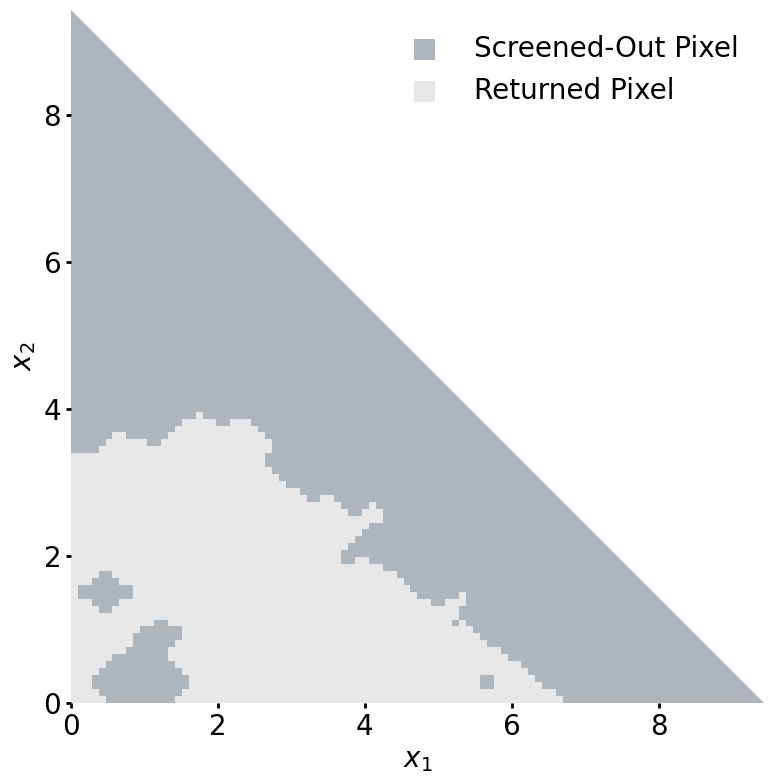

In [42]:
from matplotlib.patches import Polygon
import numpy as np
import matplotlib.pyplot as plt

# Read the ES_Confidence data
ES_Confidence = np.load('ES_Lip_Confidence.npy', allow_pickle=True)

# Ensure the values of ES_Confidence are of integer type
ES_Confidence = ES_Confidence.astype(int)
ES_Confidence = np.flip(ES_Confidence, axis=0)  # Flip along the vertical axis
ES_Confidence = np.rot90(ES_Confidence, k=3)  # Rotate

# Set parameters
resolution_1 = ES_Confidence.shape[0]  # Automatically get the resolution from the data
resolution_2 = ES_Confidence.shape[1]
scope1 = np.max(W1_data)
scope2 = np.max(W2_data)
start_point1 = 0
start_point2 = 0
step_size1 = scope1 / resolution_1
step_size2 = scope2 / resolution_2

# Generate the centers of the grid points
x = np.linspace(start_point1 + step_size1 / 2, scope1 - step_size1 / 2, resolution_1)
y = np.linspace(start_point2 + step_size2 / 2, scope2 - step_size2 / 2, resolution_2)
X, Y = np.meshgrid(x, y)

# Flatten the coordinate and color data
X_flat = X.ravel()
Y_flat = Y.ravel()
scatter_labels = ["Screened-Out Pixel", "Returned Pixel", "Over-Time Pixel"]
colors = np.array([ color_1,color_0,color_4])   # Define color order: 0-gray, 1-dark gray, 2-red, 3-blue

# Create the canvas
fig, ax = plt.subplots(figsize=(9, 9))

# Plot scatter plots of different categories and add a legend

mask_0 = ES_Confidence.ravel() == 0  # Filter out the data of the corresponding category
ax.scatter(X_flat[mask_0],Y_flat[mask_0],c=colors[0],s=25,edgecolor="none",marker="s",label=scatter_labels[0])
mask_1 = ES_Confidence.ravel() == 1  # Filter out the data of the corresponding category
ax.scatter(X_flat[mask_1],Y_flat[mask_1],c=colors[1],s=25,edgecolor="none",marker="s",label=scatter_labels[1])



# Draw the triangle
triangle_coords = [
    (0, scope2),
    (scope1, scope2),
    (scope1, 0)
]
triangle = Polygon(triangle_coords, facecolor='white', edgecolor='white', linewidth=0, zorder=2)
ax.add_patch(triangle)

# Set the range of the x-axis and y-axis
ax.set_xlim(start_point1, start_point1 + scope1)
ax.set_ylim(start_point2, start_point2 + scope2)

# Set the x-axis and y-axis ticks to every 0.1
ticks = np.arange(start_point1, start_point1 + scope1 + 0.2, 2)
ax.set_xticks(ticks)
ax.set_yticks(ticks)

# Set labels
ax.set_xlabel(r'$x_1$', fontsize=20)
ax.set_ylabel(r'$x_2$', fontsize=20)

# Keep the aspect ratio consistent
ax.set_aspect('equal')
ax.tick_params(axis='both', which='major', labelsize=20, width=2)

# Bold the axis lines
ax.spines['left'].set_linewidth(0)
ax.spines['bottom'].set_linewidth(0)

# Add a black diagonal line
plt.plot([0, scope1], [scope2, 0], 'k-', linewidth=0)  # Black diagonal line, assuming (0,1) to (1,0) is the triangle edge

# Remove top and right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add legend
plt.legend(frameon=False, fontsize=20,markerscale=3,loc='upper right')

# Show the figure
plt.show()


In [43]:
import numpy as np
ES_Confidence = np.load('ES_Lip_confidence.npy', allow_pickle=True)
ES_time_stats=np.load('ES_Lip_time_stat.npy',allow_pickle=True)
ES_time_stats = np.array(ES_time_stats).reshape(100, 100)
inference_result=[]
time_result=[]
time_returned=[]
time_screened=[]
for i in range(100):
    for j in range(100-i):
        inference_result.append(ES_Confidence[i,j])
        time_result.append(ES_time_stats[j,i])
        if ES_Confidence[i,j]==0:
            time_screened.append(ES_time_stats[j,i])
        if ES_Confidence[i,j]==1:
            time_returned.append(ES_time_stats[j,i])
            
inference_result=np.array(inference_result)
np.shape(inference_result)
np.shape(time_result)
count_of_zeros = np.sum(inference_result == 0)
print('The number of Screened-Out Solutions is',count_of_zeros , '. The number of total solutions is',np.shape(inference_result)[0])
count_of_ones = np.sum(inference_result == 1)
print('The number of returned solutions is',count_of_ones , '. The number of total solutions is',np.shape(inference_result)[0])
count_of_ts = np.sum(inference_result == 3)
print('The number of OT solutions is',count_of_ts , '. The number of total solutions is',np.shape(inference_result)[0])


print(np.quantile(time_result,0.90))
print(np.quantile(time_result,0.50))
print(np.mean(time_result))
print(np.max(time_result))
print(np.mean(time_result))
print(sum(time_result))
for i in range(len(time_result)):
    if time_result[i]>90:
        time_result[i]=90

print(sum(time_result))
print(len(time_result))

The number of Screened-Out Solutions is 3344 . The number of total solutions is 5050
The number of returned solutions is 1706 . The number of total solutions is 5050
The number of OT solutions is 0 . The number of total solutions is 5050
0.0016810503002488986
0.0009206245003952063
0.0011235865863269319
0.014690875001178938
0.0011235865863269319
5.674112260951006
5.674112260951006
5050


/var/folders/c9/6qmb3v514n75wd95b3hh4kv00000gn/T/ipykernel_62329/1317912395.py:21: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle(
/var/folders/c9/6qmb3v514n75wd95b3hh4kv00000gn/T/ipykernel_62329/1317912395.py:29: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle(


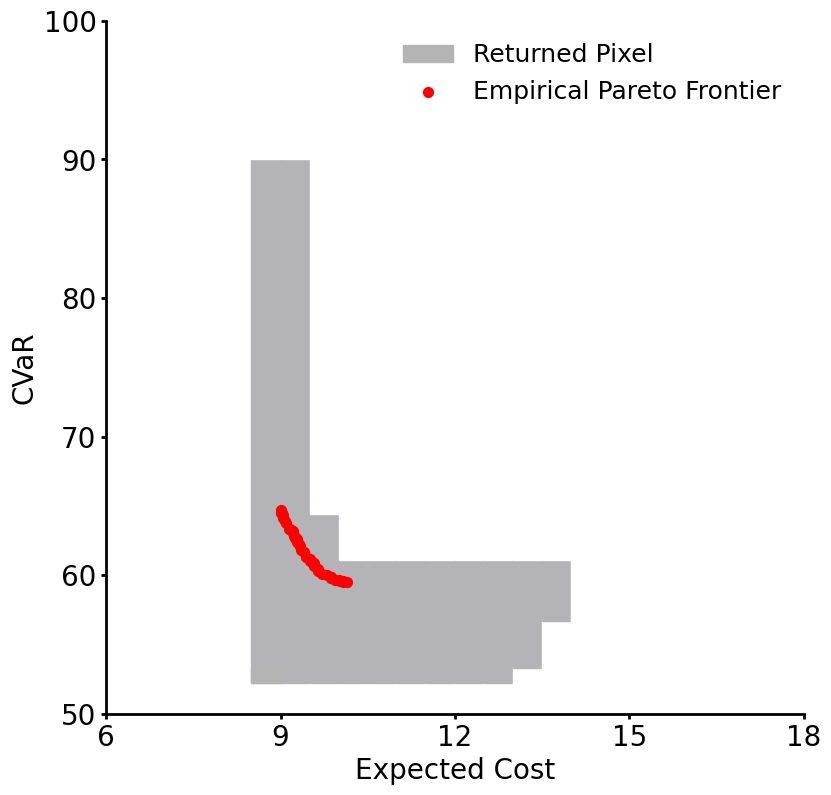

In [44]:
PF_Confidence_Lip=np.load('PF_Lip_Confidence.npy',allow_pickle=True)

resolution_1=24
resolution_2=45
scope1=12
scope2=50
step_size1=scope1/resolution_1
step_size2=scope2/resolution_2
start_point1=6
start_point2=50

# Create the canvas
fig, ax = plt.subplots(figsize=(9, 9))

# Draw the rectangular blocks in the grid
colors = ['white', "#B4B4B8", 'red','blue']

for i in range(resolution_1):
    for j in range(resolution_2):
        color_value = colors[PF_Confidence_Lip[i, j]]
        ax.add_patch(plt.Rectangle(
            (start_point1 + i * step_size1, start_point2 + j * step_size2),
            step_size1, step_size2, color=color_value, edgecolor='none'
        ))

found_indices = np.argwhere(PF_Confidence_Lip == 1)
i=found_indices[0][0]
j=found_indices[0][1]
ax.add_patch(plt.Rectangle(
            (start_point1 + i * step_size1, start_point2 + j * step_size2),
            step_size1, step_size2, color=color_3, edgecolor='none',label='Returned Pixel'
        ))

# # Draw the upper and lower bounds
# for i in range(len(LB_list)):
#     ax.plot([LB_list[i, 0], UB_list[i, 0]], [LB_list[i, 1], UB_list[i, 1]], 
#             color='black', linestyle='-', linewidth=2.5)

# Draw the Pareto Frontier
ax.scatter(pareto_frontier[:, 0], pareto_frontier[:, 1], 
           color='red', label='Empirical Pareto Frontier', s=50,zorder=3)

# Set the coordinate range
ax.set_xlim(start_point1, start_point1 + scope1)
ax.set_ylim(start_point2, start_point2 + scope2)

# Set grid lines and ticks
minor_xticks = np.arange(start_point1, start_point1 + scope1, step_size1)
minor_yticks = np.arange(start_point2, start_point2 + scope2, step_size2)
major_xticks = np.arange(start_point1, start_point1 + scope1 +0.1, 3)
major_yticks = np.arange(start_point2, start_point2 + scope2 + 5, 10)

ax.set_xticks(major_xticks)
ax.set_yticks(major_yticks)
ax.set_xticks(minor_xticks, minor=True)
ax.set_yticks(minor_yticks, minor=True)


# Set axis labels
ax.set_xlabel(r'Expected Cost', fontsize=20)
ax.set_ylabel(r'CVaR', fontsize=20)

# Remove top and right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# Bold the axis lines
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
# Set tick font size
ax.tick_params(axis='both', which='major', labelsize=20, width=2)
ax.tick_params(axis='both', which='minor', labelsize=20, width=0)
# Add legend
ax.legend(frameon=False, fontsize=18,loc='upper right')

# Show the figure
plt.show()


In [45]:
PF_Confidence_Lip=np.load('PF_Lip_Confidence.npy',allow_pickle=True)
PF_time_stats_Lip=np.load('PF_Lip_time_stat.npy',allow_pickle=True)
print(sum(PF_Confidence_Lip.ravel()==0))
print('the number of screened-out pixels is',sum(PF_Confidence_Lip.ravel()==0))
print(sum(PF_Confidence_Lip.ravel()==1))
print('the number of returned pixels is',sum(PF_Confidence_Lip.ravel()==1))
print(np.quantile(PF_time_stats_Lip,0.90))
print(np.quantile(PF_time_stats_Lip,0.50))
print(np.mean(PF_time_stats_Lip))
print(np.max(PF_time_stats_Lip))
print(sum(PF_time_stats_Lip))

942
the number of screened-out pixels is 942
138
the number of returned pixels is 138
0.0013040045007073787
0.0003177085009156144
0.0004944801749809779
0.002619000000777305
0.5340385889794561


In [46]:
PF_Confidence_Lip=np.load('PF_Lip_Confidence_relaxed.npy',allow_pickle=True)
PF_time_stats_Lip=np.load('PF_Lip_time_stat_relaxed.npy',allow_pickle=True)
print(sum(PF_Confidence_Lip.ravel()==0))
print('the number of screened-out pixels is',sum(PF_Confidence_Lip.ravel()==0))
print(sum(PF_Confidence_Lip.ravel()==1))
print('the number of returned pixels is',sum(PF_Confidence_Lip.ravel()==1))
print(np.quantile(PF_time_stats_Lip,0.90))
print(np.quantile(PF_time_stats_Lip,0.50))
print(np.mean(PF_time_stats_Lip))
print(np.max(PF_time_stats_Lip))
print(sum(PF_time_stats_Lip))

942
the number of screened-out pixels is 942
138
the number of returned pixels is 138
0.000905049400535063
0.000178770500497194
0.0003323640833497376
0.012389624998832005
0.35895321001771663


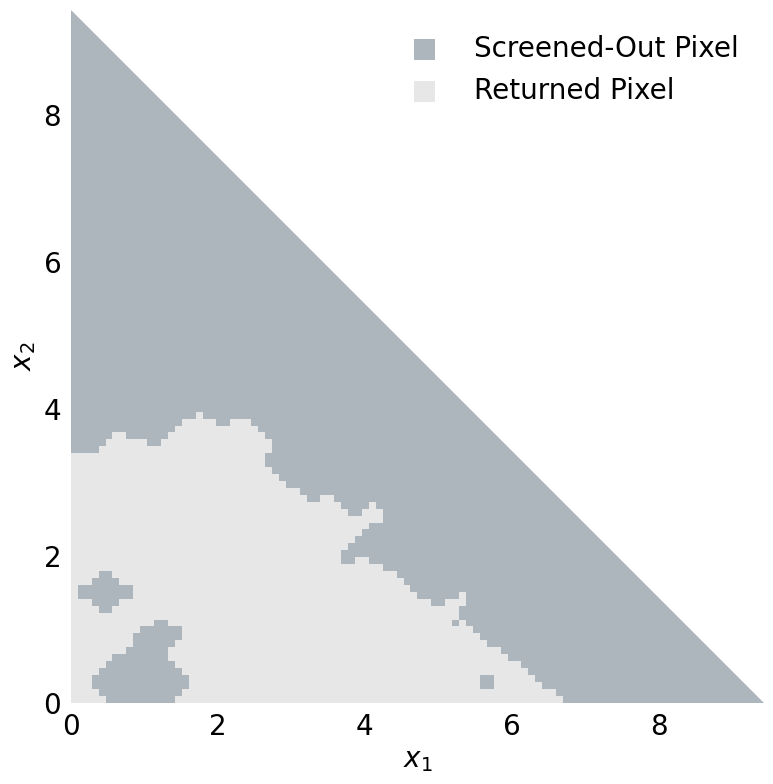

In [47]:


# Read the ES_Confidence data
ES_Confidence = np.load('ES_Lip_Confidence_relaxed.npy', allow_pickle=True)

# Ensure the values of ES_Confidence are of integer type
ES_Confidence = ES_Confidence.astype(int)
ES_Confidence = np.flip(ES_Confidence, axis=0)  # Flip along the vertical axis
ES_Confidence = np.rot90(ES_Confidence, k=3)  # Rotate

# Set parameters
resolution_1 = ES_Confidence.shape[0]  # Automatically get the resolution from the data
resolution_2 = ES_Confidence.shape[1]
scope1 = np.max(W1_data)
scope2 = np.max(W2_data)
start_point1 = 0
start_point2 = 0
step_size1 = scope1 / resolution_1
step_size2 = scope2 / resolution_2

# Generate the centers of the grid points
x = np.linspace(start_point1 + step_size1 / 2, scope1 - step_size1 / 2, resolution_1)
y = np.linspace(start_point2 + step_size2 / 2, scope2 - step_size2 / 2, resolution_2)
X, Y = np.meshgrid(x, y)

# Flatten the coordinate and color data
X_flat = X.ravel()
Y_flat = Y.ravel()
scatter_labels = ["Screened-Out Pixel", "Returned Pixel", "Over-Time Pixel"]
colors = np.array([ color_1,color_0,color_4])   # Define color order: 0-gray, 1-dark gray, 2-red, 3-blue

# Create the canvas
fig, ax = plt.subplots(figsize=(9, 9))

# Plot scatter plots of different categories and add a legend

mask_0 = ES_Confidence.ravel() == 0  # Filter out the data of the corresponding category
ax.scatter(X_flat[mask_0],Y_flat[mask_0],c=colors[0],s=25,edgecolor="none",marker="s",label=scatter_labels[0])
mask_1 = ES_Confidence.ravel() == 1  # Filter out the data of the corresponding category
ax.scatter(X_flat[mask_1],Y_flat[mask_1],c=colors[1],s=25,edgecolor="none",marker="s",label=scatter_labels[1])



# Draw the triangle
triangle_coords = [
    (0, scope2),
    (scope1, scope2),
    (scope1, 0)
]
triangle = Polygon(triangle_coords, facecolor='white', edgecolor='white', linewidth=0, zorder=2)
ax.add_patch(triangle)

# Set the range of the x-axis and y-axis
ax.set_xlim(start_point1, start_point1 + scope1)
ax.set_ylim(start_point2, start_point2 + scope2)

# Set the x-axis and y-axis ticks to every 0.1
ticks = np.arange(start_point1, start_point1 + scope1 + 0.2, 2)
ax.set_xticks(ticks)
ax.set_yticks(ticks)

# Set labels
ax.set_xlabel(r'$x_1$', fontsize=20)
ax.set_ylabel(r'$x_2$', fontsize=20)

# Keep the aspect ratio consistent
ax.set_aspect('equal')
ax.tick_params(axis='both', which='major', labelsize=20, width=0)

# Bold the axis lines
ax.spines['left'].set_linewidth(0)
ax.spines['bottom'].set_linewidth(0)

# Add a black diagonal line
plt.plot([0, scope1], [scope2, 0], 'k-', linewidth=0)  # Black diagonal line, assuming (0,1) to (1,0) is the triangle edge

# Remove top and right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add legend
plt.legend(frameon=False, fontsize=20,markerscale=3,loc='upper right')

# Show the figure
plt.show()


/var/folders/c9/6qmb3v514n75wd95b3hh4kv00000gn/T/ipykernel_62329/1945040746.py:19: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle(
/var/folders/c9/6qmb3v514n75wd95b3hh4kv00000gn/T/ipykernel_62329/1945040746.py:32: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle(


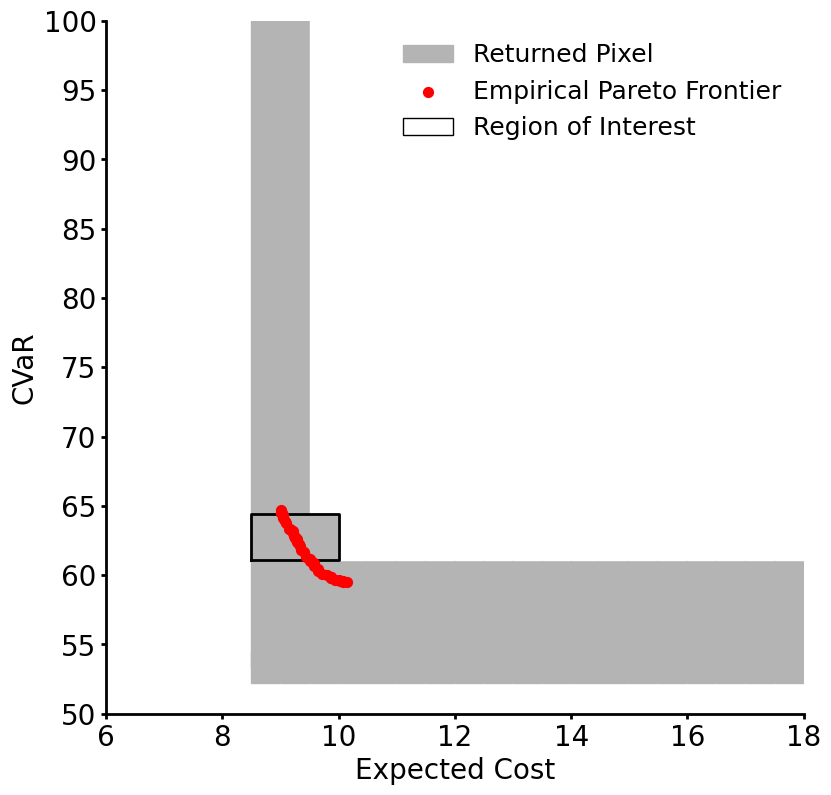

In [48]:
PF_Confidence_Lip=np.load('PF_Confidence.npy',allow_pickle=True)
# Example data
resolution_1=24
resolution_2=45
scope1=12
scope2=50
step_size1=scope1/resolution_1
step_size2=scope2/resolution_2
start_point1=6
start_point2=50
# Create the canvas
fig, ax = plt.subplots(figsize=(9, 9))

# Draw the rectangular blocks in the grid
colors = ['white',color_3, 'red', color_3]
for i in range(resolution_1):
    for j in range(resolution_2):
        color_value = colors[PF_Confidence_Lip[i, j]]
        ax.add_patch(plt.Rectangle(
            (start_point1 + i * step_size1, start_point2 + j * step_size2),
            step_size1, step_size2, color=color_value, edgecolor='none'
        ))

# Highlight a returned pixel
found_indices = np.argwhere(PF_Confidence_Lip == 1)
i = found_indices[0][0]
j = found_indices[0][1]




ax.add_patch(plt.Rectangle(
    (start_point1 + i * step_size1, start_point2 + j * step_size2),
    step_size1, step_size2, color=colors[1], edgecolor='none', label='Returned Pixel'
))

# # Draw the upper and lower bounds
# for i in range(len(LB_list)):
#     ax.plot([LB_list[i, 0], UB_list[i, 0]], [LB_list[i, 1], UB_list[i, 1]],
#             color='black', linestyle='-', linewidth=2.5)

# Draw the Pareto Frontier
ax.scatter(pareto_frontier[:, 0], pareto_frontier[:, 1],
           color='red', label='Empirical Pareto Frontier', s=50, zorder=3)

# Draw a red square
x_lower_bound = start_point1 + 5 * step_size1
x_upper_bound = start_point1 + 8 * step_size1
y_lower_bound = start_point2 + 10 * step_size2
y_upper_bound = start_point2 + 13 * step_size2

rectangle_x = [x_lower_bound, x_upper_bound, x_upper_bound, x_lower_bound, x_lower_bound]
rectangle_y = [y_lower_bound, y_lower_bound, y_upper_bound, y_upper_bound, y_lower_bound]
ax.plot(rectangle_x, rectangle_y, color='black', linewidth=2)

found_indices = np.argwhere(PF_Confidence_Lip == 1)




# Set the coordinate range
ax.set_xlim(start_point1, start_point1 + scope1)
ax.set_ylim(start_point2, start_point2 + scope2)

# Set grid lines and ticks
minor_xticks = np.arange(start_point1, start_point1 + scope1, step_size1)
minor_yticks = np.arange(start_point2, start_point2 + scope2, step_size2)
major_xticks = np.arange(start_point1, start_point1 + scope1+0.1, 2)
major_yticks = np.arange(start_point2, start_point2 + scope2 + 5, 5)

ax.set_xticks(major_xticks)
ax.set_yticks(major_yticks)
ax.set_xticks(minor_xticks, minor=True)
ax.set_yticks(minor_yticks, minor=True)

# Set axis labels
ax.set_xlabel(r'Expected Cost', fontsize=20)
ax.set_ylabel(r'CVaR', fontsize=20)

# Remove top and right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# Bold the axis lines
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
# Set tick font size
ax.tick_params(axis='both', which='major', labelsize=20, width=2)
ax.tick_params(axis='both', which='minor', labelsize=20, width=0)

ax.add_patch(plt.Rectangle(
    (start_point1 + i * step_size1, start_point2 + j * step_size2),
    step_size1, step_size2, facecolor='none', edgecolor='black', label='Region of Interest',zorder=0
))

# Add legend
ax.legend(frameon=False, fontsize=18, loc='upper right')

# Show the figure
plt.show()


In [49]:
print(x_lower_bound)
print(x_upper_bound)
print(y_lower_bound)
print(y_upper_bound)


8.5
10.0
61.111111111111114
64.44444444444444


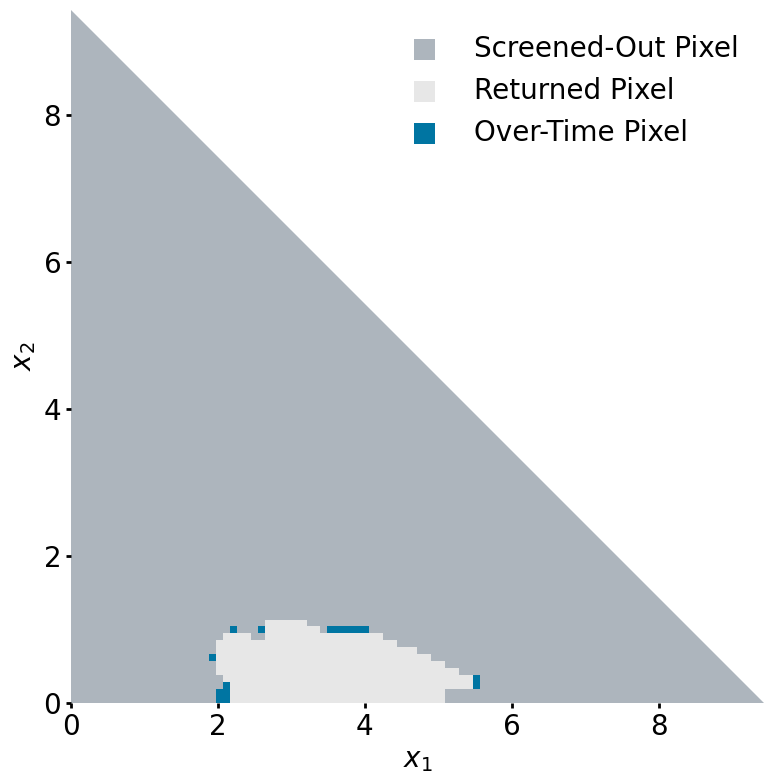

In [50]:
from matplotlib.patches import Polygon
import numpy as np
import matplotlib.pyplot as plt

# Read the ES_Confidence data
ES_Confidence = np.load('ES_Confidence_interested.npy', allow_pickle=True)

# Ensure the values of ES_Confidence are of integer type
ES_Confidence = ES_Confidence.astype(int)
ES_Confidence = np.flip(ES_Confidence, axis=0)  # Flip along the vertical axis
ES_Confidence = np.rot90(ES_Confidence, k=3)  # Rotate

# Set parameters
resolution_1 = ES_Confidence.shape[0]  # Automatically get the resolution from the data
resolution_2 = ES_Confidence.shape[1]
scope1 = np.max(W1_data)
scope2 = np.max(W2_data)
start_point1 = 0
start_point2 = 0
step_size1 = scope1 / resolution_1
step_size2 = scope2 / resolution_2

# Generate the centers of the grid points
x = np.linspace(start_point1 + step_size1 / 2, scope1 - step_size1 / 2, resolution_1)
y = np.linspace(start_point2 + step_size2 / 2, scope2 - step_size2 / 2, resolution_2)
X, Y = np.meshgrid(x, y)

# Flatten the coordinate and color data
X_flat = X.ravel()
Y_flat = Y.ravel()
scatter_labels = ["Screened-Out Pixel", "Returned Pixel", "Over-Time Pixel"]
colors = np.array([ color_1,color_0,color_4])  # Define color order: 0-gray, 1-dark gray, 2-red, 3-blue

# Create the canvas
fig, ax = plt.subplots(figsize=(9, 9))

# Plot scatter plots of different categories and add a legend

mask_0 = ES_Confidence.ravel() == 0  # Filter out the data of the corresponding category
ax.scatter(X_flat[mask_0],Y_flat[mask_0],c=colors[0],s=25,edgecolor="none",marker="s",label=scatter_labels[0])
mask_1 = ES_Confidence.ravel() == 1  # Filter out the data of the corresponding category
ax.scatter(X_flat[mask_1],Y_flat[mask_1],c=colors[1],s=25,edgecolor="none",marker="s",label=scatter_labels[1])
mask_2 = ES_Confidence.ravel() == 3  # Filter out the data of the corresponding category
ax.scatter(X_flat[mask_2],Y_flat[mask_2],c=colors[2],s=25,edgecolor="none",marker="s",label=scatter_labels[2])


# Draw the triangle
triangle_coords = [
    (0, scope2),
    (scope1, scope2),
    (scope1, 0)
]
triangle = Polygon(triangle_coords, facecolor='white', edgecolor='white', linewidth=0, zorder=2)
ax.add_patch(triangle)

# Set the range of the x-axis and y-axis
ax.set_xlim(start_point1, start_point1 + scope1)
ax.set_ylim(start_point2, start_point2 + scope2)

# Set the x-axis and y-axis ticks to every 0.1
ticks = np.arange(start_point1, start_point1 + scope1 + 0.2, 2)
ax.set_xticks(ticks)
ax.set_yticks(ticks)

# Set labels
ax.set_xlabel(r'$x_1$', fontsize=20)
ax.set_ylabel(r'$x_2$', fontsize=20)

# Keep the aspect ratio consistent
ax.set_aspect('equal')
ax.tick_params(axis='both', which='major', labelsize=20, width=2)

# Bold the axis lines
ax.spines['left'].set_linewidth(0)
ax.spines['bottom'].set_linewidth(0)

# Add a black diagonal line
#plt.plot([0, 1], [1, 0], 'k-', linewidth=2)  # Black diagonal line, assuming (0,1) to (1,0) is the triangle edge

# Remove top and right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add legend
plt.legend(frameon=False, fontsize=20,markerscale=3,loc='upper right')

# Show the figure
plt.show()

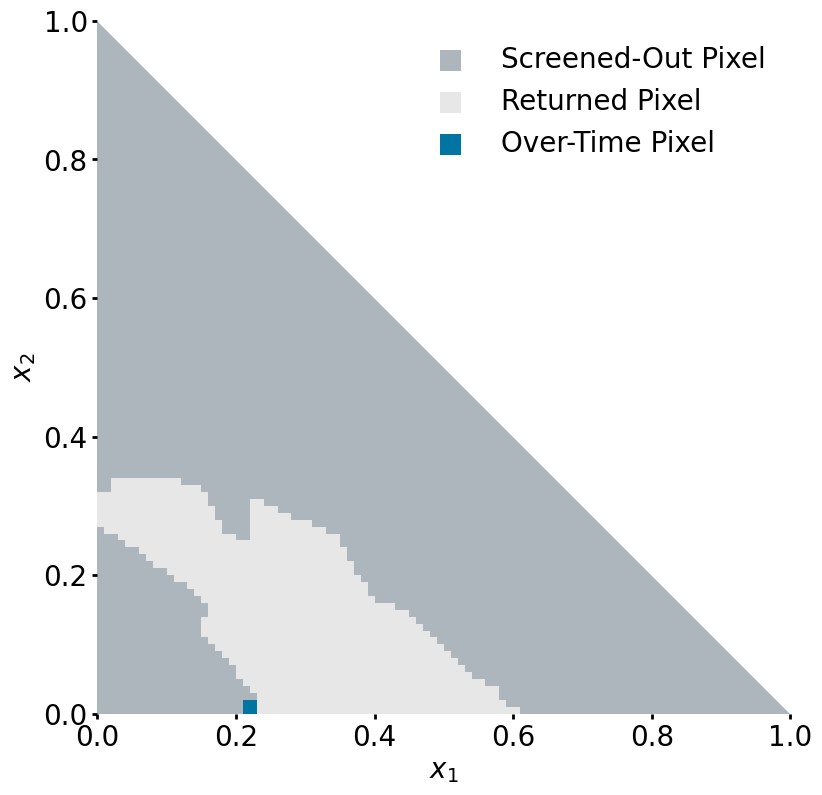

In [51]:
from matplotlib.patches import Polygon
import numpy as np
import matplotlib.pyplot as plt

# Read the ES_Confidence data
ES_Confidence = np.load('ES_Confidence_relaxed.npy', allow_pickle=True)

# Ensure the values of ES_Confidence are of integer type
ES_Confidence = ES_Confidence.astype(int)
ES_Confidence = np.flip(ES_Confidence, axis=0)  # Flip along the vertical axis
ES_Confidence = np.rot90(ES_Confidence, k=3)  # Rotate

# Set parameters
resolution_1 = ES_Confidence.shape[0]  # Automatically get the resolution from the data
resolution_2 = ES_Confidence.shape[1]
scope1 = 1
scope2 = 1
start_point1 = 0
start_point2 = 0
step_size1 = scope1 / resolution_1
step_size2 = scope2 / resolution_2

# Generate the centers of the grid points
x = np.linspace(start_point1 + step_size1 / 2, scope1 - step_size1 / 2, resolution_1)
y = np.linspace(start_point2 + step_size2 / 2, scope2 - step_size2 / 2, resolution_2)
X, Y = np.meshgrid(x, y)

# Flatten the coordinate and color data
X_flat = X.ravel()
Y_flat = Y.ravel()
scatter_labels = ["Screened-Out Pixel", "Returned Pixel", "Over-Time Pixel"]
colors = np.array([ color_1,color_0,color_4])  # Define color order: 0-gray, 1-dark gray, 2-red, 3-blue

# Create the canvas
fig, ax = plt.subplots(figsize=(9, 9))

# Plot scatter plots of different categories and add a legend

mask_0 = ES_Confidence.ravel() == 0  # Filter out the data of the corresponding category
ax.scatter(X_flat[mask_0],Y_flat[mask_0],c=colors[0],s=25,edgecolor="none",marker="s",label=scatter_labels[0])
mask_1 = ES_Confidence.ravel() == 1  # Filter out the data of the corresponding category
ax.scatter(X_flat[mask_1],Y_flat[mask_1],c=colors[1],s=25,edgecolor="none",marker="s",label=scatter_labels[1])
mask_2 = ES_Confidence.ravel() == 3  # Filter out the data of the corresponding category
ax.scatter(X_flat[mask_2],Y_flat[mask_2],c=colors[2],s=25,edgecolor="none",marker="s",label=scatter_labels[2])


# Draw the triangle
triangle_coords = [
    (0, 1),
    (1, 1),
    (1, 0)
]
triangle = Polygon(triangle_coords, facecolor='white', edgecolor='white', linewidth=0, zorder=2)
ax.add_patch(triangle)

# Set the range of the x-axis and y-axis
ax.set_xlim(start_point1, start_point1 + scope1)
ax.set_ylim(start_point2, start_point2 + scope2)

# Set the x-axis and y-axis ticks to every 0.1
ticks = np.arange(start_point1, start_point1 + scope1 + 0.2, 0.2)
ax.set_xticks(ticks)
ax.set_yticks(ticks)

# Set labels
ax.set_xlabel(r'$x_1$', fontsize=20)
ax.set_ylabel(r'$x_2$', fontsize=20)

# Keep the aspect ratio consistent
ax.set_aspect('equal')
ax.tick_params(axis='both', which='major', labelsize=20, width=2)

# Bold the axis lines
ax.spines['left'].set_linewidth(0)
ax.spines['bottom'].set_linewidth(0)

# Add a black diagonal line
#plt.plot([0, 1], [1, 0], 'k-', linewidth=2)  # Black diagonal line, assuming (0,1) to (1,0) is the triangle edge

# Remove top and right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add legend
plt.legend(frameon=False, fontsize=20,markerscale=3,loc='upper right')

# Show the figure
plt.show()

In [52]:
ES_Confidence = np.load('ES_Confidence_relaxed.npy', allow_pickle=True)
ES_time_stats=np.load('ES_time_stats_relaxed.npy',allow_pickle=True)

In [53]:
import numpy as np
ES_Confidence = np.load('ES_Confidence_relaxed.npy', allow_pickle=True)
ES_time_stats=np.load('ES_time_stats_relaxed.npy',allow_pickle=True)
ES_time_stats = np.array(ES_time_stats).reshape(100, 100)
inference_result=[]
time_result=[]
time_returned=[]
time_screened=[]
for i in range(100):
    for j in range(100-i):
        inference_result.append(ES_Confidence[i,j])
        time_result.append(ES_time_stats[j,i])
        if ES_Confidence[i,j]==0:
            time_screened.append(ES_time_stats[j,i])
        if ES_Confidence[i,j]==1:
            time_returned.append(ES_time_stats[j,i])
            
inference_result=np.array(inference_result)
np.shape(inference_result)
np.shape(time_result)
count_of_zeros = np.sum(inference_result == 0)
print('The number of Screened-Out Solutions is',count_of_zeros , '. The number of total solutions is',np.shape(inference_result)[0])
count_of_ones = np.sum(inference_result == 1)
print('The number of returned solutions is',count_of_ones , '. The number of total solutions is',np.shape(inference_result)[0])
count_of_ts = np.sum(inference_result == 3)
print('The number of OT solutions is',count_of_ts , '. The number of total solutions is',np.shape(inference_result)[0])


print(np.quantile(time_result,0.90))
print(np.quantile(time_result,0.50))
print(np.mean(time_result))
print(np.max(time_result))
print(np.mean(time_result))
print(sum(time_result))
for i in range(len(time_result)):
    if time_result[i]>90:
        time_result[i]=90

print(sum(time_result))
print(len(time_result))

The number of Screened-Out Solutions is 4080 . The number of total solutions is 5050
The number of returned solutions is 966 . The number of total solutions is 5050
The number of OT solutions is 4 . The number of total solutions is 5050
0.23292296670017554
0.0306343749999769
0.20210225034197715
90.01151541599984
0.20210225034197715
1020.6163642269846
1020.5895585609849
5050


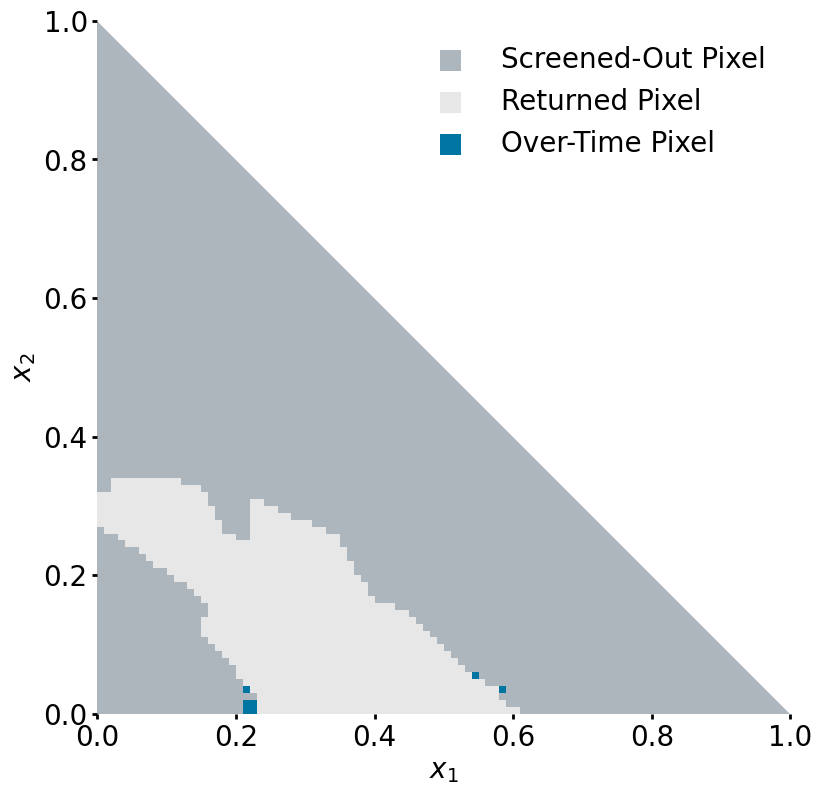

In [54]:
from matplotlib.patches import Polygon
import numpy as np
import matplotlib.pyplot as plt

# Read the ES_Confidence data
ES_Confidence = np.load('ES_Confidence.npy', allow_pickle=True)

# Ensure the values of ES_Confidence are of integer type
ES_Confidence = ES_Confidence.astype(int)
ES_Confidence = np.flip(ES_Confidence, axis=0)  # Flip along the vertical axis
ES_Confidence = np.rot90(ES_Confidence, k=3)  # Rotate

# Set parameters
resolution_1 = ES_Confidence.shape[0]  # Automatically get the resolution from the data
resolution_2 = ES_Confidence.shape[1]
scope1 = 1
scope2 = 1
start_point1 = 0
start_point2 = 0
step_size1 = scope1 / resolution_1
step_size2 = scope2 / resolution_2

# Generate the centers of the grid points
x = np.linspace(start_point1 + step_size1 / 2, scope1 - step_size1 / 2, resolution_1)
y = np.linspace(start_point2 + step_size2 / 2, scope2 - step_size2 / 2, resolution_2)
X, Y = np.meshgrid(x, y)

# Flatten the coordinate and color data
X_flat = X.ravel()
Y_flat = Y.ravel()
scatter_labels = ["Screened-Out Pixel", "Returned Pixel", "Over-Time Pixel"]
colors = np.array([ color_1,color_0,color_4])  # Define color order: 0-gray, 1-dark gray, 2-red, 3-blue

# Create the canvas
fig, ax = plt.subplots(figsize=(9, 9))

# Plot scatter plots of different categories and add a legend

mask_0 = ES_Confidence.ravel() == 0  # Filter out the data of the corresponding category
ax.scatter(X_flat[mask_0],Y_flat[mask_0],c=colors[0],s=25,edgecolor="none",marker="s",label=scatter_labels[0])
mask_1 = ES_Confidence.ravel() == 1  # Filter out the data of the corresponding category
ax.scatter(X_flat[mask_1],Y_flat[mask_1],c=colors[1],s=25,edgecolor="none",marker="s",label=scatter_labels[1])
mask_2 = ES_Confidence.ravel() == 3  # Filter out the data of the corresponding category
ax.scatter(X_flat[mask_2],Y_flat[mask_2],c=colors[2],s=25,edgecolor="none",marker="s",label=scatter_labels[2])


# Draw the triangle
triangle_coords = [
    (0, 1),
    (1, 1),
    (1, 0)
]
triangle = Polygon(triangle_coords, facecolor='white', edgecolor='white', linewidth=0, zorder=2)
ax.add_patch(triangle)

# Set the range of the x-axis and y-axis
ax.set_xlim(start_point1, start_point1 + scope1)
ax.set_ylim(start_point2, start_point2 + scope2)

# Set the x-axis and y-axis ticks to every 0.1
ticks = np.arange(start_point1, start_point1 + scope1 + 0.2, 0.2)
ax.set_xticks(ticks)
ax.set_yticks(ticks)

# Set labels
ax.set_xlabel(r'$x_1$', fontsize=20)
ax.set_ylabel(r'$x_2$', fontsize=20)

# Keep the aspect ratio consistent
ax.set_aspect('equal')
ax.tick_params(axis='both', which='major', labelsize=20, width=2)

# Bold the axis lines
ax.spines['left'].set_linewidth(0)
ax.spines['bottom'].set_linewidth(0)

# Add a black diagonal line
#plt.plot([0, 1], [1, 0], 'k-', linewidth=2)  # Black diagonal line, assuming (0,1) to (1,0) is the triangle edge

# Remove top and right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add legend
plt.legend(frameon=False, fontsize=20,markerscale=3,loc='upper right')

# Show the figure
plt.show()

In [55]:
import numpy as np
ES_Confidence = np.load('ES_Confidence.npy', allow_pickle=True)
ES_time_stats=np.load('ES_time_stats.npy',allow_pickle=True)
ES_time_stats = np.array(ES_time_stats).reshape(100, 100)
inference_result=[]
time_result=[]
time_returned=[]
time_screened=[]
ES_Confidence_C=[]
for i in range(100):
    for j in range(100-i):
        inference_result.append(ES_Confidence[i,j])
        time_result.append(ES_time_stats[j,i])
        if ES_Confidence[i,j]==0:
            time_screened.append(ES_time_stats[j,i])
        if ES_Confidence[i,j]==1:
            time_returned.append(ES_time_stats[j,i])
            
inference_result=np.array(inference_result)
np.shape(inference_result)
np.shape(time_result)
count_of_zeros = np.sum(inference_result == 0)
print('The number of Screened-Out Solutions is',count_of_zeros , '. The number of total solutions is',np.shape(inference_result)[0])
count_of_ones = np.sum(inference_result == 1)
print('The number of returned solutions is',count_of_ones , '. The number of total solutions is',np.shape(inference_result)[0])
count_of_ts = np.sum(inference_result == 3)
print('The number of OT solutions is',count_of_ts , '. The number of total solutions is',np.shape(inference_result)[0])


print(np.quantile(time_result,0.90))
print(np.quantile(time_result,0.50))
print(np.mean(time_result))
print(np.max(time_result))
print(np.mean(time_result))
print(sum(time_result))
for i in range(len(time_result)):
    if time_result[i]>90:
        time_result[i]=90

print(sum(time_result))
print(len(time_result))

The number of Screened-Out Solutions is 4077 . The number of total solutions is 5050
The number of returned solutions is 966 . The number of total solutions is 5050
The number of OT solutions is 7 . The number of total solutions is 5050
1.0360276827000066
0.18359549999999558
0.5595383074920794
90.09319058300002
0.5595383074920794
2825.6684528349906
2825.4090468759905
5050


In [56]:
PF_Confidence_convexity=np.load('PF_Confidence_relaxed.npy',allow_pickle=True)
np.shape(PF_Confidence_convexity)


(24, 45)

In [57]:
PF_Confidence_convexity[22,44]

0

/var/folders/c9/6qmb3v514n75wd95b3hh4kv00000gn/T/ipykernel_62329/585612271.py:23: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle(
/var/folders/c9/6qmb3v514n75wd95b3hh4kv00000gn/T/ipykernel_62329/585612271.py:31: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle(
/var/folders/c9/6qmb3v514n75wd95b3hh4kv00000gn/T/ipykernel_62329/585612271.py:51: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle(


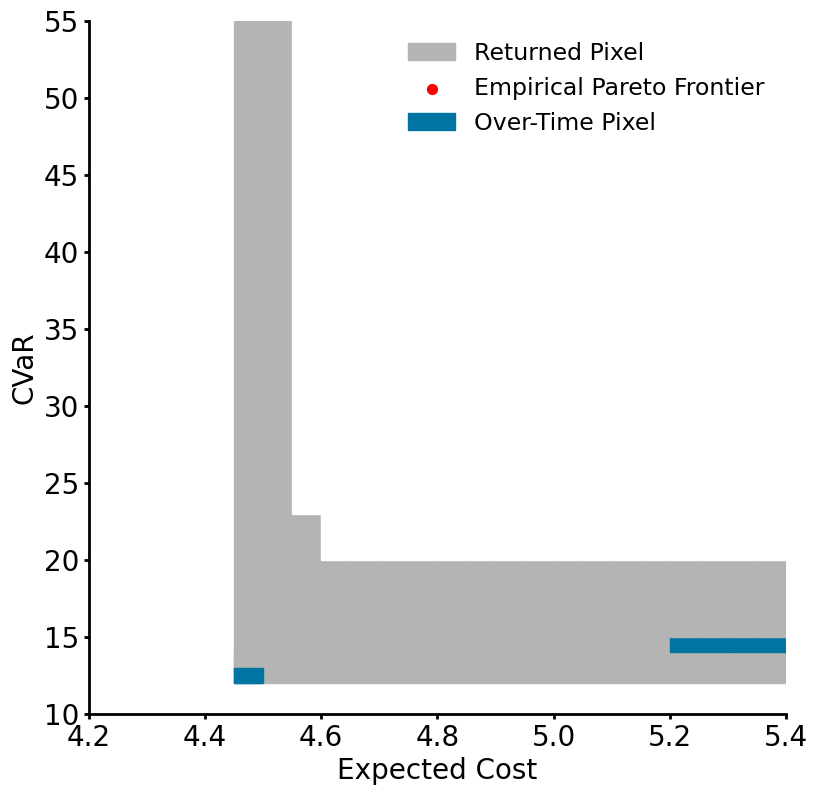

In [58]:
PF_Confidence_convexity=np.load('PF_Confidence_relaxed.npy',allow_pickle=True)

# Example data
resolution_1 = 24
resolution_2 = 45
scope1 = 1.2
scope2 = 45
step_size1 = scope1 / resolution_1
step_size2 = scope2 / resolution_2
start_point1 = 4.2
start_point2 = 10


# Create the canvas
fig, ax = plt.subplots(figsize=(9, 9))

# Draw the rectangular blocks in the grid
colors = ['white', color_3, 'red',color_4]

for i in range(resolution_1):
    for j in range(resolution_2):
        color_value = colors[PF_Confidence_convexity[i, j]]
        ax.add_patch(plt.Rectangle(
            (start_point1 + i * step_size1, start_point2 + j * step_size2),
            step_size1, step_size2, color=color_value, edgecolor='none'
        ))

found_indices = np.argwhere(PF_Confidence_convexity == 1)
i=found_indices[0][0]
j=found_indices[0][1]
ax.add_patch(plt.Rectangle(
            (start_point1 + i * step_size1, start_point2 + j * step_size2),
            step_size1, step_size2, color=colors[1], edgecolor='none',label='Returned Pixel'
        ))




# # Draw the upper and lower bounds
# for i in range(len(LB_list)):
#     ax.plot([LB_list[i, 0], UB_list[i, 0]], [LB_list[i, 1], UB_list[i, 1]], 
#             color='black', linestyle='-', linewidth=2.5)

# Draw the Pareto Frontier
ax.scatter(pareto_frontier[:, 0], pareto_frontier[:, 1], 
          color='red', label='Empirical Pareto Frontier', s=50,zorder=3)

found_indices = np.argwhere(PF_Confidence_convexity == 3)
i=found_indices[0][0]
j=found_indices[0][1]
ax.add_patch(plt.Rectangle(
            (start_point1 + i * step_size1, start_point2 + j * step_size2),
            step_size1, step_size2, color=colors[3], edgecolor='none',label='Over-Time Pixel'
        ))

# Set the coordinate range
ax.set_xlim(start_point1, start_point1 + scope1)
ax.set_ylim(start_point2, start_point2 + scope2)

# Set grid lines and ticks
minor_xticks = np.arange(start_point1, start_point1 + scope1, step_size1)
minor_yticks = np.arange(start_point2, start_point2 + scope2, step_size2)
major_xticks = np.arange(start_point1, start_point1 + scope1 , 0.2)
major_yticks = np.arange(start_point2, start_point2 + scope2 + 5, 5)

ax.set_xticks(major_xticks)
ax.set_yticks(major_yticks)
ax.set_xticks(minor_xticks, minor=True)
ax.set_yticks(minor_yticks, minor=True)


# Set axis labels
ax.set_xlabel(r'Expected Cost', fontsize=20)
ax.set_ylabel(r'CVaR', fontsize=20)

# Remove top and right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# Bold the axis lines
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
# Set tick font size
ax.tick_params(axis='both', which='major', labelsize=20, width=2)
ax.tick_params(axis='both', which='minor', labelsize=20, width=0)
# Add legend
ax.legend(frameon=False, fontsize=17,loc='upper right')

# Show the figure
plt.show()


In [59]:
print(sum(PF_Confidence_convexity.ravel()==0))
print(sum(PF_Confidence_convexity.ravel()==1))
print(sum(PF_Confidence_convexity.ravel()==3))

855
220
5


In [60]:
PF_time_stats_convexity=np.load('PF_time_stats_relaxed.npy',allow_pickle=True)
print(np.quantile(PF_time_stats_convexity,0.90))
print(np.quantile(PF_time_stats_convexity,0.50))
print(np.mean(PF_time_stats_convexity))
print(np.max(PF_time_stats_convexity))
print(sum(sum(PF_time_stats_convexity)))
PF_time_stats_convexity=PF_time_stats_convexity.ravel()
for i in range(len(PF_time_stats_convexity)):
    if PF_time_stats_convexity[i]>90:
        PF_time_stats_convexity[i]=90
print(sum(PF_time_stats_convexity))

1.0063446954996835
0.0009570209999765211
0.738514641651868
90.05157458299982
797.5958129840174
797.4926137760185


In [61]:
205+19

224

/var/folders/c9/6qmb3v514n75wd95b3hh4kv00000gn/T/ipykernel_62329/570776723.py:23: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle(
/var/folders/c9/6qmb3v514n75wd95b3hh4kv00000gn/T/ipykernel_62329/570776723.py:31: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle(
/var/folders/c9/6qmb3v514n75wd95b3hh4kv00000gn/T/ipykernel_62329/570776723.py:51: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle(


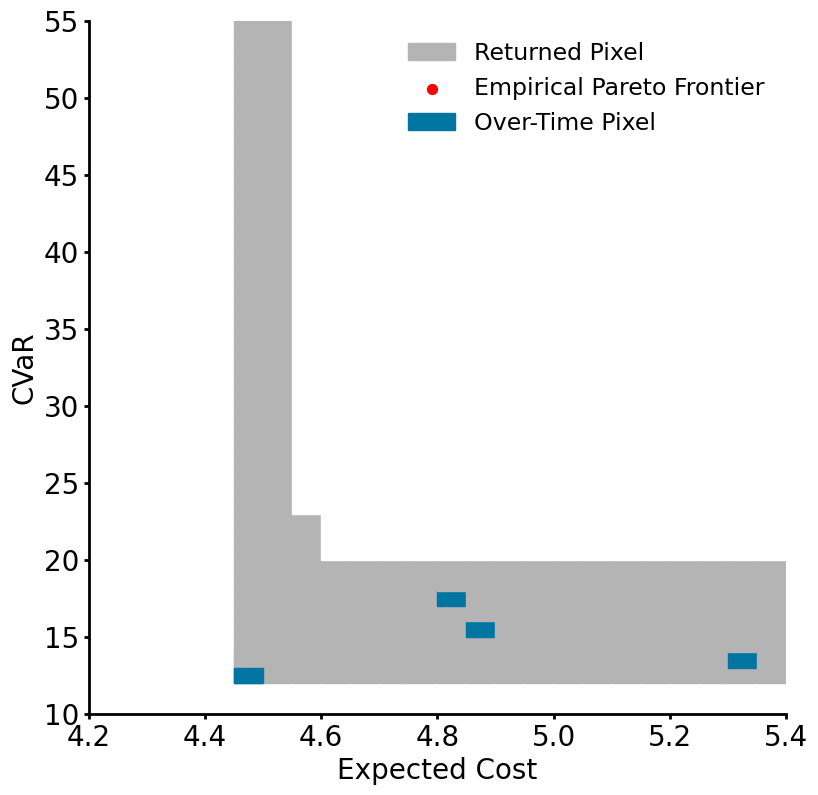

In [62]:
PF_Confidence_convexity=np.load('PF_Confidence.npy',allow_pickle=True)

# Example data
resolution_1 = 24
resolution_2 = 45
scope1 = 1.2
scope2 = 45
step_size1 = scope1 / resolution_1
step_size2 = scope2 / resolution_2
start_point1 = 4.2
start_point2 = 10


# Create the canvas
fig, ax = plt.subplots(figsize=(9, 9))

# Draw the rectangular blocks in the grid
colors = ['white', color_3, 'red',color_4]

for i in range(resolution_1):
    for j in range(resolution_2):
        color_value = colors[PF_Confidence_convexity[i, j]]
        ax.add_patch(plt.Rectangle(
            (start_point1 + i * step_size1, start_point2 + j * step_size2),
            step_size1, step_size2, color=color_value, edgecolor='none'
        ))

found_indices = np.argwhere(PF_Confidence_convexity == 1)
i=found_indices[0][0]
j=found_indices[0][1]
ax.add_patch(plt.Rectangle(
            (start_point1 + i * step_size1, start_point2 + j * step_size2),
            step_size1, step_size2, color=colors[1], edgecolor='none',label='Returned Pixel'
        ))




# # Draw the upper and lower bounds
# for i in range(len(LB_list)):
#     ax.plot([LB_list[i, 0], UB_list[i, 0]], [LB_list[i, 1], UB_list[i, 1]], 
#             color='black', linestyle='-', linewidth=2.5)

# Draw the Pareto Frontier
ax.scatter(pareto_frontier[:, 0], pareto_frontier[:, 1], 
           color='red', label='Empirical Pareto Frontier', s=50,zorder=3)

found_indices = np.argwhere(PF_Confidence_convexity == 3)
i=found_indices[0][0]
j=found_indices[0][1]
ax.add_patch(plt.Rectangle(
            (start_point1 + i * step_size1, start_point2 + j * step_size2),
            step_size1, step_size2, color=colors[3], edgecolor='none',label='Over-Time Pixel'
        ))

# Set the coordinate range
ax.set_xlim(start_point1, start_point1 + scope1)
ax.set_ylim(start_point2, start_point2 + scope2)

# Set grid lines and ticks
minor_xticks = np.arange(start_point1, start_point1 + scope1, step_size1)
minor_yticks = np.arange(start_point2, start_point2 + scope2, step_size2)
major_xticks = np.arange(start_point1, start_point1 + scope1 , 0.2)
major_yticks = np.arange(start_point2, start_point2 + scope2 + 5, 5)

ax.set_xticks(major_xticks)
ax.set_yticks(major_yticks)
ax.set_xticks(minor_xticks, minor=True)
ax.set_yticks(minor_yticks, minor=True)


# Set axis labels
ax.set_xlabel(r'Expected Cost', fontsize=20)
ax.set_ylabel(r'CVaR', fontsize=20)

# Remove top and right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# Bold the axis lines
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
# Set tick font size
ax.tick_params(axis='both', which='major', labelsize=20, width=2)
ax.tick_params(axis='both', which='minor', labelsize=20, width=0)
# Add legend
ax.legend(frameon=False, fontsize=17,loc='upper right')

# Show the figure
plt.show()


In [63]:
PF_time_stats_convexity=np.load('PF_time_stats.npy',allow_pickle=True)
print(np.quantile(PF_time_stats_convexity,0.90))
print(np.quantile(PF_time_stats_convexity,0.50))
print(np.mean(PF_time_stats_convexity))
print(np.max(PF_time_stats_convexity))
print(sum(sum(PF_time_stats_convexity)))
PF_time_stats_convexity=PF_time_stats_convexity.ravel()
for i in range(len(PF_time_stats_convexity)):
    if PF_time_stats_convexity[i]>90:
        PF_time_stats_convexity[i]=90
print(sum(PF_time_stats_convexity))



2.0227134788002337
0.0019190419998267316
1.0548766086703676
90.17567354099992
1139.266737363997
1138.9681553639975


In [64]:
print(sum(PF_Confidence_convexity.ravel()==0))
print(sum(PF_Confidence_convexity.ravel()==1))
print(sum(PF_Confidence_convexity.ravel()==3))

855
221
4


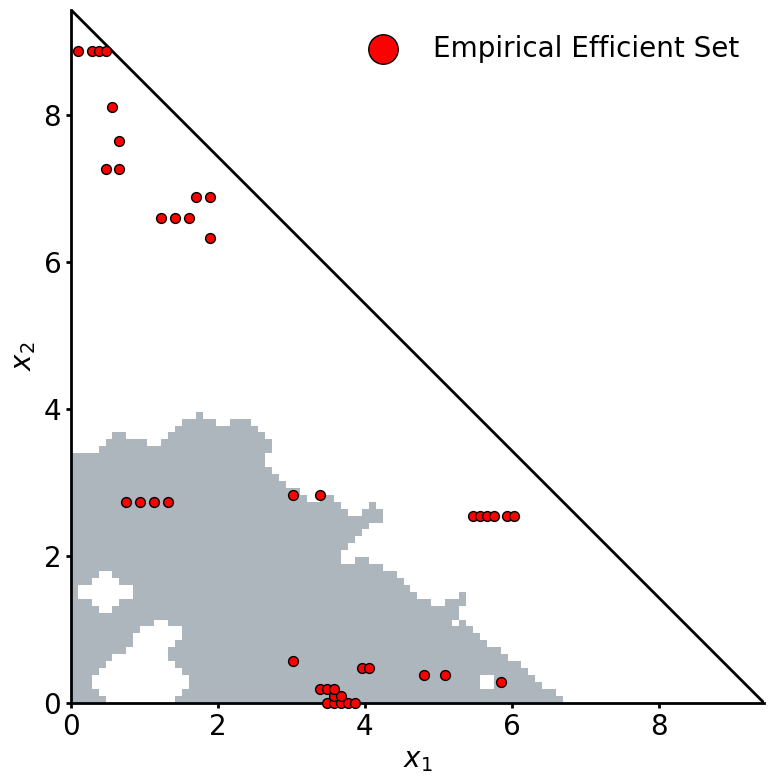

In [65]:
from matplotlib.patches import Polygon
import numpy as np
import matplotlib.pyplot as plt

# Read the ES_Confidence data
ES_Confidence = np.load('ES_Lip_Confidence.npy', allow_pickle=True)

# Ensure the values of ES_Confidence are of integer type
ES_Confidence = ES_Confidence.astype(int)
ES_Confidence = np.flip(ES_Confidence, axis=0)  # Flip along the vertical axis
ES_Confidence = np.rot90(ES_Confidence, k=3)  # Rotate

# Set parameters
resolution_1 = ES_Confidence.shape[0]  # Automatically get the resolution from the data
resolution_2 = ES_Confidence.shape[1]
scope1 = np.max(W1_data)
scope2 = np.max(W2_data)
start_point1 = 0
start_point2 = 0
step_size1 = scope1 / resolution_1
step_size2 = scope2 / resolution_2

# Generate the centers of the grid points
x = np.linspace(start_point1 + step_size1 / 2, scope1 - step_size1 / 2, resolution_1)
y = np.linspace(start_point2 + step_size2 / 2, scope2 - step_size2 / 2, resolution_2)
X, Y = np.meshgrid(x, y)

# Flatten the coordinate and color data
X_flat = X.ravel()
Y_flat = Y.ravel()
scatter_labels = ["Screened-Out Pixel", "Returned Pixel", "Over-Time Pixel"]
colors = np.array([ color_1,color_0,color_4])   # Define color order: 0-gray, 1-dark gray, 2-red, 3-blue

# Create the canvas
fig, ax = plt.subplots(figsize=(9, 9))

# Plot scatter plots of different categories and add a legend

mask_0 = ES_Confidence.ravel() == 0  # Filter out the data of the corresponding category
#ax.scatter(X_flat[mask_0],Y_flat[mask_0],c=colors[0],s=25,edgecolor="none",marker="s",label=scatter_labels[0])
mask_1 = ES_Confidence.ravel() == 1  # Filter out the data of the corresponding category
ax.scatter(X_flat[mask_1],Y_flat[mask_1],c=colors[0],s=25,edgecolor="none",marker="s",label='')



# Draw the triangle
triangle_coords = [
    (0, scope2),
    (scope1, scope2),
    (scope1, 0)
]
triangle = Polygon(triangle_coords, facecolor='white', edgecolor='white', linewidth=0, zorder=2)
ax.add_patch(triangle)

# Set the range of the x-axis and y-axis
ax.set_xlim(start_point1, start_point1 + scope1)
ax.set_ylim(start_point2, start_point2 + scope2)

# Set the x-axis and y-axis ticks to every 0.1
ticks = np.arange(start_point1, start_point1 + scope1 + 0.2, 2)
ax.set_xticks(ticks)
ax.set_yticks(ticks)

# Set labels
ax.set_xlabel(r'$x_1$', fontsize=20)
ax.set_ylabel(r'$x_2$', fontsize=20)

# Keep the aspect ratio consistent
ax.set_aspect('equal')
ax.tick_params(axis='both', which='major', labelsize=20, width=2)

# Bold the axis lines
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
plt.plot([0, scope1], [scope2, 0], 'k-', linewidth=2)  # Black diagonal line, assuming (0,1) to (1,0) is the triangle edge


# Annotate the solutions corresponding to the Pareto frontier on the plane plot
pareto_feasible_solutions = feasible_region[membership]  # Find the solutions corresponding to the Pareto frontier based on membership
plt.scatter(pareto_feasible_solutions[:, 0], pareto_feasible_solutions[:, 1], color='r', s=50, label='Empirical Efficient Set', edgecolor='black',zorder=10,clip_on=False)
# Remove top and right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add legend
plt.legend(frameon=False, fontsize=20,markerscale=3,loc='upper right')

# Show the figure
plt.show()

/var/folders/c9/6qmb3v514n75wd95b3hh4kv00000gn/T/ipykernel_62329/203005530.py:23: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle(
/var/folders/c9/6qmb3v514n75wd95b3hh4kv00000gn/T/ipykernel_62329/203005530.py:31: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle(


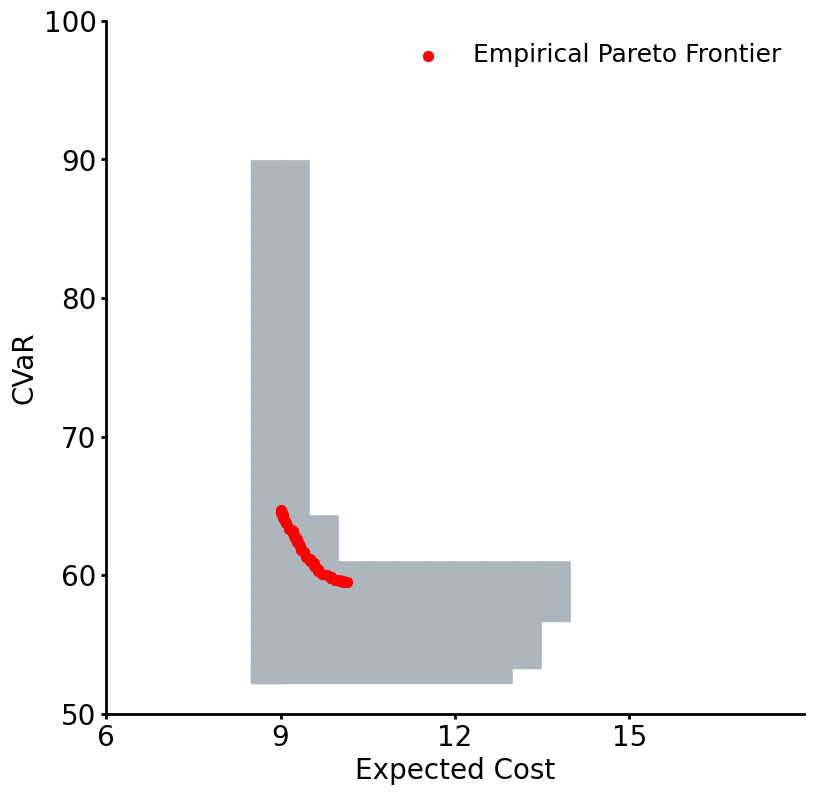

In [66]:
PF_Confidence_Lip=np.load('PF_Lip_Confidence.npy',allow_pickle=True)

# Example data
resolution_1=24
resolution_2=45
scope1=12
scope2=50
step_size1=scope1/resolution_1
step_size2=scope2/resolution_2
start_point1=6
start_point2=50


# Create the canvas
fig, ax = plt.subplots(figsize=(9, 9))

# Draw the rectangular blocks in the grid
colors = ['white', color_1, 'red','blue']

for i in range(resolution_1):
    for j in range(resolution_2):
        color_value = colors[PF_Confidence_Lip[i, j]]
        ax.add_patch(plt.Rectangle(
            (start_point1 + i * step_size1, start_point2 + j * step_size2),
            step_size1, step_size2, color=color_value, edgecolor='none'
        ))

found_indices = np.argwhere(PF_Confidence_Lip == 1)
i=found_indices[0][0]
j=found_indices[0][1]
ax.add_patch(plt.Rectangle(
            (start_point1 + i * step_size1, start_point2 + j * step_size2),
            step_size1, step_size2, color=color_1, edgecolor='none',label=''
        ))

# # Draw the upper and lower bounds
# for i in range(len(LB_list)):
#     ax.plot([LB_list[i, 0], UB_list[i, 0]], [LB_list[i, 1], UB_list[i, 1]], 
#             color='black', linestyle='-', linewidth=2.5)

# Draw the Pareto Frontier
ax.scatter(pareto_frontier[:, 0], pareto_frontier[:, 1], 
           color='red', label='Empirical Pareto Frontier', s=50,zorder=3)

# Set the coordinate range
ax.set_xlim(start_point1, start_point1 + scope1)
ax.set_ylim(start_point2, start_point2 + scope2)

# Set grid lines and ticks
minor_xticks = np.arange(start_point1, start_point1 + scope1, step_size1)
minor_yticks = np.arange(start_point2, start_point2 + scope2, step_size2)
major_xticks = np.arange(start_point1, start_point1 + scope1 , 3)
major_yticks = np.arange(start_point2, start_point2 + scope2 + 5, 10)

ax.set_xticks(major_xticks)
ax.set_yticks(major_yticks)
ax.set_xticks(minor_xticks, minor=True)
ax.set_yticks(minor_yticks, minor=True)


# Set axis labels
ax.set_xlabel(r'Expected Cost', fontsize=20)
ax.set_ylabel(r'CVaR', fontsize=20)

# Remove top and right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# Bold the axis lines
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
# Set tick font size
ax.tick_params(axis='both', which='major', labelsize=20, width=2)
ax.tick_params(axis='both', which='minor', labelsize=20, width=0)
# Add legend
ax.legend(frameon=False, fontsize=18,loc='upper right')

# Show the figure
plt.show()